# Entrega 1 — Priorizar el despacho de una cuadrilla

**Machine Learning** · Grupos de 4 · 10 % de la calificación final · Vence el **martes 6 de octubre**

**Integrantes**

1. 
2.
3.
4.

---

La consigna completa está en `enunciado.pdf`. Este notebook fija **las trece secciones y su orden**; la corrección se hace **contra el enunciado**, no contra el template.

Condiciones de uso:

- Las celdas de texto describen qué se pide en cada sección y **no se eliminan**. Las respuestas escritas se agregan en las celdas marcadas para eso, que pueden extenderse tanto como haga falta.
- Las celdas de código llegan vacías y pueden dividirse en tantas como convenga.
- **El notebook se entrega ejecutado de punta a punta**, con todas las salidas visibles y en el orden en que se generaron. Un notebook sin ejecutar no está entregado.
- Toda celda con aleatoriedad fija su semilla, y la semilla se mantiene igual en todas las comparaciones del notebook: dos resultados que se comparan no pueden diferir por la partición.

**Los datos se construyen uniendo dos fuentes**, y esa construcción es parte del trabajo:

1. El archivo abierto de OSE «Solicitudes y reclamos operativos 2024», que se descarga de <https://datos.ose.com.uy/dataset/reclamos-operativos>. Es un ZIP de unos 10 MB que descomprime a un CSV de unos 114 MB **separado por punto y coma**.
2. `data/entregas_reclamos_complemento.csv`, que aporta la cátedra.

La ruta del archivo descargado se declara **en la celda de configuración de abajo y en ningún otro lado**, de modo que el notebook pueda reproducirse cambiando una sola línea. En Colab, los dos archivos deben subirse o montarse antes de la primera lectura.

### Configuración: importaciones, rutas y semilla

Importar las bibliotecas que el trabajo use, declarar las rutas de los dos archivos y fijar la semilla. Nada de esta celda se evalúa.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score,
                             make_scorer, precision_recall_curve, precision_score, recall_score,
                             roc_curve)
from sklearn.model_selection import (GridSearchCV, KFold, StratifiedKFold, cross_val_predict,
                                     cross_validate)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*unknown categories.*")
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 4)

# Paleta del curso
AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, GRIS = "#A3477F", "#89A943", "#9A9A9A"

# ── Rutas: la única línea a cambiar para reproducir es RUTA_OSE ─────────────
RUTA_OSE = Path("data/solicitudes_reclamos_operativos_2024.zip")   # el ZIP tal como se descarga, o el CSV descomprimido
RUTA_COMPLEMENTO = Path("data/entregas_reclamos_complemento.csv")
RUTA_RESULTADOS = Path("resultados")                               # caché de la sección 10

# ── Semilla y particiones: las mismas en todas las comparaciones ────────────
SEMILLA = 42
K_FOLDS = 5
np.random.seed(SEMILLA)
CV_REG = KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEMILLA)
CV_CLF = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEMILLA)

# ── Cifras del caso (enunciado.pdf) ─────────────────────────────────────────
# ⚠ VERIFICAR CONTRA enunciado.pdf: plazo y costos son provisorios.
PLAZO_HORAS = 48            # plazo comprometido de resolución, en horas
COSTO_PRIORIZAR = 2_000     # $U por reclamo despachado con prioridad (se paga acierte o no)
COSTO_INCUMPLIR = 10_000    # $U por reclamo que incumple el plazo sin haber sido priorizado
COSTOS = {                  # costo de cada casilla de la matriz de confusión, por reclamo
    "VP": COSTO_PRIORIZAR,  # se priorizó y habría incumplido: se paga la prioridad, se evita el incumplimiento
    "FP": COSTO_PRIORIZAR,  # se priorizó y no hacía falta
    "FN": COSTO_INCUMPLIR,  # no se priorizó e incumplió
    "VN": 0,                # no se priorizó y cumplió
}
VOLUMEN_ANUAL = None        # reclamos por año; None = filas del archivo de OSE 2024

# En Colab: si faltan los archivos, se suben a mano y se dejan en data/
if not (RUTA_OSE.exists() and RUTA_COMPLEMENTO.exists()):
    try:
        from google.colab import files  # type: ignore
    except ImportError as exc:
        raise FileNotFoundError(f"Faltan {RUTA_OSE} o {RUTA_COMPLEMENTO}") from exc
    RUTA_OSE.parent.mkdir(exist_ok=True)
    print("Subir el ZIP de OSE y el complemento de la cátedra")
    for nombre in files.upload():
        Path(nombre).rename(RUTA_OSE.parent / nombre)

## 1. Ingesta, unión y auditoría del conjunto

**Primero, la construcción de la tabla de trabajo.** Documentar cuántas filas trae cada fuente, cuántas sobreviven al filtro, cuántas quedan después de la unión y **qué garantiza que la unión no perdió ni multiplicó registros**. Una unión que cambia el número de filas sin explicación es un error de la sección, no un detalle.

**Después, la auditoría**, antes de ajustar ningún modelo: dimensiones, tipos, resumen descriptivo, distribución de cada variable, valores faltantes por columna y el patrón que siguen, filas repetidas, valores imposibles y cardinalidad de las variables categóricas.

Para **cada** variable con faltantes, diagnosticar el mecanismo —MCAR, MAR o MNAR— y sostener el diagnóstico con el contraste que lo separa de las otras dos alternativas. Cuando el mecanismo no sea diagnosticable con los datos observados, decirlo y explicar por qué. **El tratamiento se deriva del diagnóstico, no al revés.**

**Por último, construir la respuesta binaria** a partir del plazo comprometido, dejando dicho qué se hizo con los registros para los que esa construcción no tiene sentido.

Un hallazgo sin la cifra o el gráfico que lo produce no cuenta como hallazgo.

In [2]:
### 1.1 Ingesta y unión
CLAVE_OSE, CLAVE_COMP = "id_reclamo_operativo_m", "id_reclamo"

ose_crudo = pd.read_csv(RUTA_OSE, sep=";", dtype=str)
complemento = pd.read_csv(RUTA_COMPLEMENTO, dtype={CLAVE_COMP: str})
if VOLUMEN_ANUAL is None:
    VOLUMEN_ANUAL = len(ose_crudo)

print(f"OSE crudo:    {ose_crudo.shape[0]:>7,} filas × {ose_crudo.shape[1]} columnas")
print(f"Complemento:  {complemento.shape[0]:>7,} filas × {complemento.shape[1]} columnas")

# Garantía 1: la clave es única en las dos fuentes, así que ninguna fila puede multiplicarse.
print(f"\nclave única en OSE: {ose_crudo[CLAVE_OSE].is_unique} · "
      f"en el complemento: {complemento[CLAVE_COMP].is_unique}")
assert ose_crudo[CLAVE_OSE].is_unique and complemento[CLAVE_COMP].is_unique

# Filtro por identificador: quedan los reclamos que la cátedra complementó.
ose_filtrado = ose_crudo[ose_crudo[CLAVE_OSE].isin(complemento[CLAVE_COMP])]
sin_par = int((~complemento[CLAVE_COMP].isin(ose_crudo[CLAVE_OSE])).sum())

# Garantía 2: validate="one_to_one" hace fallar la unión ante cualquier clave repetida, y la
# unión externa con indicator=True deja a la vista cualquier fila que venga de un solo lado.
union = ose_filtrado.merge(complemento, left_on=CLAVE_OSE, right_on=CLAVE_COMP,
                           how="outer", validate="one_to_one", indicator=True)
print("\norigen de cada fila tras la unión externa:")
print(union["_merge"].value_counts().to_string())
assert (union["_merge"] == "both").all()
assert len(union) == len(ose_filtrado) == len(complemento)
df = union.drop(columns=["_merge", CLAVE_COMP])

trazabilidad = pd.DataFrame([
    ("Archivo de OSE, crudo", len(ose_crudo), "una fila por reclamo; clave única"),
    ("Complemento de la cátedra", len(complemento), "una fila por reclamo; clave única"),
    ("Tras el filtro por identificador", len(ose_filtrado),
     f"reclamos de OSE presentes en el complemento; {sin_par} ids del complemento sin par"),
    ("Tras la unión", len(df), "1:1 validado; 0 filas de un solo lado"),
], columns=["Paso", "Filas", "Comentario"])
display(trazabilidad)

OSE crudo:    390,886 filas × 18 columnas
Complemento:    3,964 filas × 4 columnas

clave única en OSE: True · en el complemento: True



origen de cada fila tras la unión externa:
_merge
both          3964
left_only        0
right_only       0


,Paso,Filas,Comentario
0,"Archivo de OSE, crudo",390886,una fila por reclamo; clave única
1,Complemento de la cátedra,3964,una fila por reclamo; clave única
2,Tras el filtro por identificador,3964,reclamos de OSE presentes en el complemento; 0...
3,Tras la unión,3964,1:1 validado; 0 filas de un solo lado


In [3]:
### 1.2 Tipos: limpieza determinista de formato (no estima nada de la muestra)
df = df.rename(columns={CLAVE_OSE: "id", "id_tipo_reclamo_operativo": "tipo_reclamo"})
for c in df.columns:
    if df[c].dtype == object and c != "id":
        df[c] = df[c].str.strip()          # tipo_reclamo trae espacios iniciales
FECHAS = ["fecha_ingreso", "fecha_resuelto_visita", "fecha_resuelto_sistema", "fecha_foto"]
for c in FECHAS:
    df[c] = pd.to_datetime(df[c], format="%Y/%m/%d %H:%M")
for c in ["año", "tiempo_resolucion_minutos", "id_centro_tecnico"]:
    df[c] = pd.to_numeric(df[c])

print(f"Tabla unida: {df.shape[0]:,} filas × {df.shape[1]} columnas")
display(pd.DataFrame({"tipo": df.dtypes.astype(str), "ejemplo": df.iloc[0].astype(str)}))

Tabla unida: 3,964 filas × 21 columnas


,tipo,ejemplo
año,int64,2024
region,object,CENTRO
departamento,object,CANELONES
fecha_ingreso,datetime64[ns],2024-11-26 18:02:00
id,object,0004598C26700BC
tipo_reclamo,object,RP Denuncia de Pérdida
tipo_complejidad,object,Equipo de 1
ausencia_agua,object,AUSENCIA AGUA
baja_presion,object,SIN BAJA PRESION
inunda,object,NO INUNDA


In [4]:
### 1.3 Resumen descriptivo y cardinalidad
NUM_AUDIT = ["tiempo_resolucion_minutos", "distancia_centro_km", "conexiones_afectadas",
             "calificacion_atencion", "id_centro_tecnico", "año"]
display(df[NUM_AUDIT].describe().T)
display(df[FECHAS].describe().T)

CAT_AUDIT = [c for c in df.columns if df[c].dtype == object and c != "id"]
cardinalidad = pd.DataFrame({
    "niveles": df[CAT_AUDIT].nunique(),
    "nivel más frecuente": df[CAT_AUDIT].mode().iloc[0],
    "% del más frecuente": df[CAT_AUDIT].apply(lambda s: s.value_counts(normalize=True).iloc[0]),
    "niveles con < 10 filas": df[CAT_AUDIT].apply(lambda s: int((s.value_counts() < 10).sum())),
}).sort_values("niveles")
display(cardinalidad)
print("columnas constantes:", [c for c in df.columns if df[c].nunique(dropna=False) == 1])
print(f"id_centro_tecnico: {df.id_centro_tecnico.nunique()} niveles (es un código, no una magnitud)")

,count,mean,std,min,25%,50%,75%,max
tiempo_resolucion_minutos,3964.0,-1785.6375,178937.4822,-6935087.0,128.750,948.000,2565.000,523868.0
distancia_centro_km,3964.0,244.7257,3488.2025,0.4,8.145,28.165,55.415,87510.0
conexiones_afectadas,3709.0,44.3858,55.5503,1.0,14.000,27.000,54.000,670.0
calificacion_atencion,3500.0,4.1748,0.7894,1.0,3.800,4.400,4.800,5.0
id_centro_tecnico,3964.0,83.0749,63.4962,-1.0,40.000,101.000,103.000,511.0
año,3964.0,2024.0000,0.0000,2024.0,2024.000,2024.000,2024.000,2024.0


,count,mean,min,25%,50%,75%,max
fecha_ingreso,3964,2024-06-26 04:14:17.058526976,2024-01-01 19:24:00,2024-03-20 09:24:45,2024-06-17 14:59:30,2024-09-30 09:44:45,2024-12-31 15:48:00
fecha_resuelto_visita,3964,2024-03-13 14:53:18.920282624,1900-01-01 00:00:00,2024-03-21 17:38:15,2024-06-19 14:30:00,2024-10-01 10:30:00,2025-12-08 08:05:00
fecha_resuelto_sistema,3964,2024-03-19 03:43:14.303733760,1900-01-01 00:00:00,2024-03-23 04:36:00,2024-06-21 08:44:30,2024-10-02 09:45:15,2025-12-09 08:01:00
fecha_foto,3964,2025-12-19 23:59:59.999999744,2025-12-20 00:00:00,2025-12-20 00:00:00,2025-12-20 00:00:00,2025-12-20 00:00:00,2025-12-20 00:00:00


,niveles,nivel más frecuente,% del más frecuente,niveles con < 10 filas
baja_presion,2,SIN BAJA PRESION,0.8782,0
inunda,2,NO INUNDA,0.9531,0
ausencia_agua,2,CON AGUA,0.6014,0
estado_resuelto,3,Resuelto Procedente,0.8850,1
tipo_complejidad,5,Equipo de 1,0.7043,1
region,7,MDEO,0.4390,0
tipo_reclamo,9,RP Denuncia de Pérdida,0.4324,1
grupo_orden,15,RECLAMOS OPERATIVOS,0.7921,6
departamento,19,MONTEVIDEO,0.4390,0
tipo_orden,25,RP REPARACIÓN PÉRDIDA,0.5484,12


columnas constantes: ['año', 'fecha_foto']
id_centro_tecnico: 83 niveles (es un código, no una magnitud)


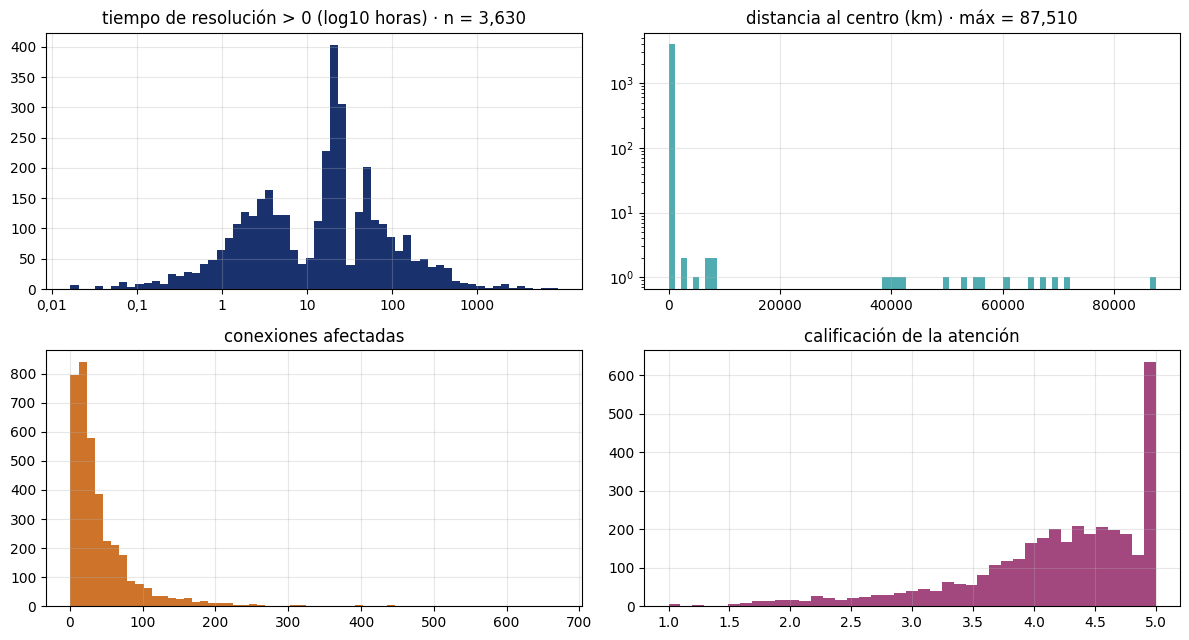

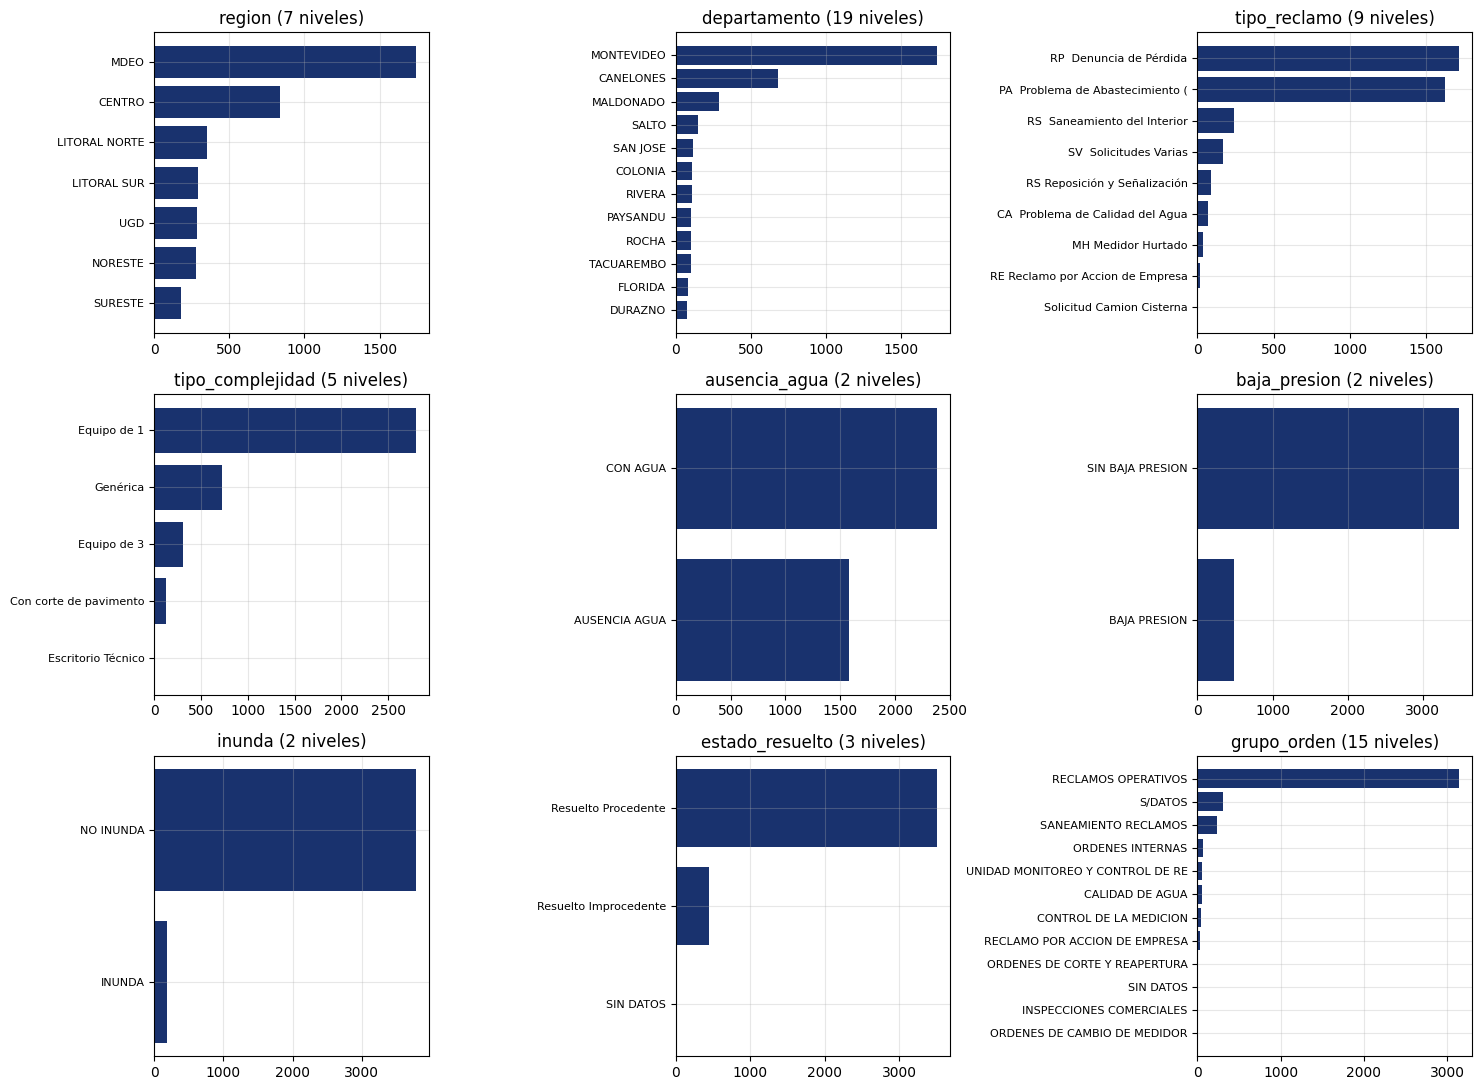

In [5]:
### 1.4 Distribución de cada variable
t_min = df.tiempo_resolucion_minutos
fig, ejes = plt.subplots(2, 2, figsize=(12, 6.5))
h_pos = t_min[t_min > 0] / 60
ejes[0, 0].hist(np.log10(h_pos), bins=60, color=AZUL)
ejes[0, 0].set_title(f"tiempo de resolución > 0 (log10 horas) · n = {len(h_pos):,}")
ejes[0, 0].set_xticks([-2, -1, 0, 1, 2, 3], ["0,01", "0,1", "1", "10", "100", "1000"])
ejes[0, 1].hist(df.distancia_centro_km, bins=80, color=TURQUESA, log=True)
ejes[0, 1].set_title(f"distancia al centro (km) · máx = {df.distancia_centro_km.max():,.0f}")
ejes[1, 0].hist(df.conexiones_afectadas.dropna(), bins=60, color=NARANJA)
ejes[1, 0].set_title("conexiones afectadas")
ejes[1, 1].hist(df.calificacion_atencion.dropna(), bins=41, color=VIOLETA)
ejes[1, 1].set_title("calificación de la atención")
plt.tight_layout(); plt.show()

CAT_GRAF = ["region", "departamento", "tipo_reclamo", "tipo_complejidad", "ausencia_agua",
            "baja_presion", "inunda", "estado_resuelto", "grupo_orden"]
fig, ejes = plt.subplots(3, 3, figsize=(15, 11))
for eje, c in zip(ejes.ravel(), CAT_GRAF):
    vc = df[c].value_counts().head(12)[::-1]
    eje.barh([s[:32] for s in vc.index], vc.values, color=AZUL)
    eje.set_title(f"{c} ({df[c].nunique()} niveles)")
    eje.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

In [6]:
### 1.5 Valores imposibles y centinelas
es_1900_v = df.fecha_resuelto_visita.dt.year == 1900
es_1900_s = df.fecha_resuelto_sistema.dt.year == 1900
visita_menos_ingreso = (df.fecha_resuelto_visita - df.fecha_ingreso).dt.total_seconds() / 60
UMBRAL_METROS = 150   # ver la cola de la distancia abajo

imposibles = pd.DataFrame([
    ("tiempo_resolucion_minutos == -1", (t_min == -1).sum(), "centinela 'sin valor' de los metadatos"),
    ("tiempo_resolucion_minutos < 0 y != -1", ((t_min < 0) & (t_min != -1)).sum(), "resuelto antes de ingresar"),
    ("fecha_resuelto_visita == 1900-01-01", es_1900_v.sum(), "centinela 'sin fecha'"),
    ("fecha_resuelto_sistema == 1900-01-01", es_1900_s.sum(), "centinela 'sin fecha'"),
    ("fecha_resuelto_visita < fecha_ingreso", (visita_menos_ingreso < 0).sum(), "imposible"),
    ("id_centro_tecnico == -1", (df.id_centro_tecnico == -1).sum(), "centinela 'sin valor'"),
    ("estado_resuelto == 'SIN DATOS'", (df.estado_resuelto == "SIN DATOS").sum(), "centinela"),
    ("tipo_orden == 'SIN DATOS'", (df.tipo_orden == "SIN DATOS").sum(), "centinela de los metadatos"),
    ("tipo_orden == 'S/DATOS'", (df.tipo_orden == "S/DATOS").sum(), "segundo código, no documentado"),
    ("distancia_centro_km > 150", (df.distancia_centro_km > UMBRAL_METROS).sum(), "fuera de escala"),
    ("conexiones_afectadas < 1", (df.conexiones_afectadas < 1).sum(), "imposible"),
    ("calificacion_atencion fuera de [1, 5]", (~df.calificacion_atencion.dropna().between(1, 5)).sum(), "imposible"),
], columns=["condición", "filas", "lectura"])
display(imposibles)

coincide = (t_min - visita_menos_ingreso).abs() <= 1
print(f"tiempo_resolucion_minutos = visita − ingreso (±1 min) en {coincide[~es_1900_v].mean():.1%} "
      "de las filas con fecha de visita: la respuesta ES esa diferencia.")
print("\n¿el -1 es siempre centinela?")
display(pd.crosstab(t_min == -1, es_1900_v, rownames=["tiempo == -1"], colnames=["visita en 1900"]))
neg = t_min[(t_min < 0) & ~es_1900_v] / 60
print(f"tiempos negativos reales: {len(neg)}; mediana {neg.median():.1f} h; "
      f"{(neg > -24).mean():.0%} a menos de un día antes del ingreso; mínimo {neg.min():,.0f} h")

grandes = df.loc[df.distancia_centro_km > UMBRAL_METROS, "distancia_centro_km"].sort_values()
resto = df.loc[df.distancia_centro_km <= UMBRAL_METROS, "distancia_centro_km"]
print(f"\ndistancia: el resto termina en {resto.max():.2f} km y el siguiente valor es {grandes.min():,.0f}")
print("valores > 150:          ", grandes.to_numpy())
print("los mismos ÷ 1000:      ", (grandes / 1000).round(2).to_numpy())
print(f"→ caen dentro del rango del resto [{resto.min():.2f}, {resto.max():.2f}] km: "
      "están cargados en metros (el 400 → 0,40 km coincide con el mínimo observado).")

,condición,filas,lectura
0,tiempo_resolucion_minutos == -1,10,centinela 'sin valor' de los metadatos
1,tiempo_resolucion_minutos < 0 y != -1,321,resuelto antes de ingresar
2,fecha_resuelto_visita == 1900-01-01,9,centinela 'sin fecha'
3,fecha_resuelto_sistema == 1900-01-01,9,centinela 'sin fecha'
4,fecha_resuelto_visita < fecha_ingreso,331,imposible
5,id_centro_tecnico == -1,319,centinela 'sin valor'
6,estado_resuelto == 'SIN DATOS',9,centinela
7,tipo_orden == 'SIN DATOS',9,centinela de los metadatos
8,tipo_orden == 'S/DATOS',310,"segundo código, no documentado"
9,distancia_centro_km > 150,24,fuera de escala


tiempo_resolucion_minutos = visita − ingreso (±1 min) en 100.0% de las filas con fecha de visita: la respuesta ES esa diferencia.

¿el -1 es siempre centinela?


visita en 1900,False,True
tiempo == -1,,
False,3954,0
True,1,9


tiempos negativos reales: 322; mediana -2.4 h; 91% a menos de un día antes del ingreso; mínimo -115,585 h

distancia: el resto termina en 119.52 km y el siguiente valor es 400
valores > 150:           [  400.   400.   400.  2450.  2750.  5130.  6620.  6980.  7980.  8680.
 39230. 39800. 41020. 41860. 49790. 53550. 54950. 56510. 60350. 65360.
 67180. 69820. 71420. 87510.]
los mismos ÷ 1000:       [ 0.4   0.4   0.4   2.45  2.75  5.13  6.62  6.98  7.98  8.68 39.23 39.8
 41.02 41.86 49.79 53.55 54.95 56.51 60.35 65.36 67.18 69.82 71.42 87.51]
→ caen dentro del rango del resto [0.40, 119.52] km: están cargados en metros (el 400 → 0,40 km coincide con el mínimo observado).


In [7]:
### 1.6 Filas repetidas
COLS_SIN_ID = [c for c in df.columns if c != "id"]
repetidas = df.duplicated(COLS_SIN_ID, keep=False)
print(f"ids repetidos: {df.id.duplicated().sum()}")
print(f"filas idénticas en todo salvo el id: {repetidas.sum()} "
      f"({df.duplicated(COLS_SIN_ID).sum()} copias sobrantes)")
display(df.loc[repetidas].sort_values(COLS_SIN_ID)[
    ["id", "fecha_ingreso", "departamento", "tipo_reclamo", "tiempo_resolucion_minutos",
     "distancia_centro_km", "conexiones_afectadas", "calificacion_atencion"]].head(8))
comp_cols = ["distancia_centro_km", "conexiones_afectadas", "calificacion_atencion"]
ose_cols = [c for c in COLS_SIN_ID if c not in comp_cols]
print(f"pares que coinciden en las columnas de OSE: {df.duplicated(ose_cols).sum()}; "
      f"de ellos, con el complemento también idéntico: {df.duplicated(COLS_SIN_ID).sum()}")
print(f"en el archivo completo de OSE hay {ose_crudo.duplicated([c for c in ose_crudo.columns if c != CLAVE_OSE]).sum():,} "
      "filas iguales a otra salvo el id: el reingreso del mismo reclamo con otro número es un fenómeno de la fuente.")

ids repetidos: 0
filas idénticas en todo salvo el id: 64 (32 copias sobrantes)


,id,fecha_ingreso,departamento,tipo_reclamo,tiempo_resolucion_minutos,distancia_centro_km,conexiones_afectadas,calificacion_atencion
834,35827B8B58010BD,2024-01-19 15:43:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,924,56.39,11.0,4.6
1774,7275861C790E9B7,2024-01-19 15:43:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,924,56.39,11.0,4.6
676,2B1B50E46F7603C,2024-01-19 18:28:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,763,34.59,97.0,4.6
1102,48242DD631171F4,2024-01-19 18:28:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,763,34.59,97.0,4.6
598,26CF0F5C2A4AD96,2024-02-02 10:47:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,222,74.94,50.0,5.0
1649,69D03004FBD5ED1,2024-02-02 10:47:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,222,74.94,50.0,5.0
594,2689611EDFDF107,2024-02-28 12:41:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,-91,24.57,30.0,4.1
2844,B70BAEA5AB4FD30,2024-02-28 12:41:00,CANELONES,PA Problema de Abastecimiento (falta de agua ...,-91,24.57,30.0,4.1


pares que coinciden en las columnas de OSE: 32; de ellos, con el complemento también idéntico: 32


en el archivo completo de OSE hay 10,346 filas iguales a otra salvo el id: el reingreso del mismo reclamo con otro número es un fenómeno de la fuente.


,NaN en el archivo,codificados como centinela,total,%
calificacion_atencion,464,0,464,11.71
tipo_orden,0,319,319,8.05
id_centro_tecnico,0,319,319,8.05
grupo_orden,0,319,319,8.05
conexiones_afectadas,255,0,255,6.43
fecha_resuelto_visita,0,9,9,0.23
estado_resuelto,0,9,9,0.23
fecha_resuelto_sistema,0,9,9,0.23
tiempo_resolucion_minutos,0,9,9,0.23


combinaciones de faltantes (fila = patrón):


,calificacion_atencion,tipo_orden,id_centro_tecnico,grupo_orden,conexiones_afectadas,fecha_resuelto_visita,estado_resuelto,fecha_resuelto_sistema,tiempo_resolucion_minutos,filas
0,False,False,False,False,False,False,False,False,False,3004
1,True,False,False,False,False,False,False,False,False,402
2,False,True,True,True,False,False,False,False,False,265
3,False,False,False,False,True,False,False,False,False,208
4,True,False,False,False,True,False,False,False,False,31
5,True,True,True,True,False,False,False,False,False,30
6,False,True,True,True,True,False,False,False,False,14
7,False,True,True,True,False,True,True,True,True,8
8,False,True,True,True,True,True,True,True,True,1
9,True,True,True,True,True,False,False,False,False,1


co-ocurrencia (filas con faltante en la fila Y en la columna):


,calificacion_atencion,tipo_orden,id_centro_tecnico,grupo_orden,conexiones_afectadas,fecha_resuelto_visita,estado_resuelto,fecha_resuelto_sistema,tiempo_resolucion_minutos
calificacion_atencion,464,31,31,31,32,0,0,0,0
tipo_orden,31,319,319,319,16,9,9,9,9
id_centro_tecnico,31,319,319,319,16,9,9,9,9
grupo_orden,31,319,319,319,16,9,9,9,9
conexiones_afectadas,32,16,16,16,255,1,1,1,1
fecha_resuelto_visita,0,9,9,9,1,9,9,9,9
estado_resuelto,0,9,9,9,1,9,9,9,9
fecha_resuelto_sistema,0,9,9,9,1,9,9,9,9
tiempo_resolucion_minutos,0,9,9,9,1,9,9,9,9


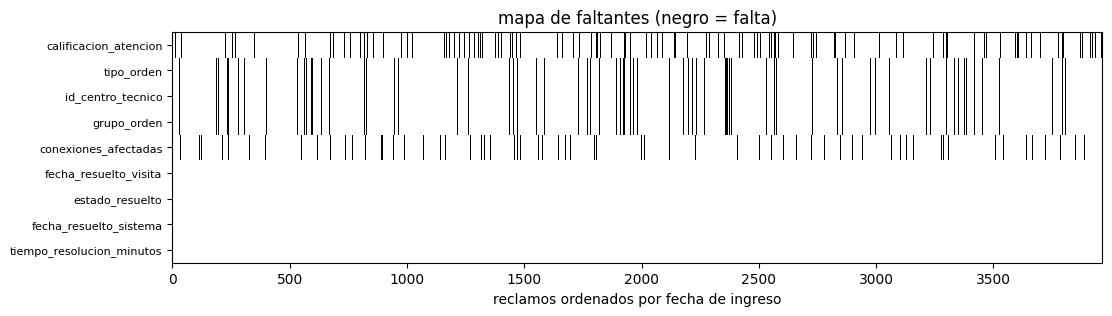

In [8]:
### 1.7 Faltantes por columna y su patrón
# Se reemplazan los centinelas por faltantes solo para medirlos; la tabla de trabajo se arma en 1.9.
aud = df.copy()
centinela_tiempo = (t_min == -1) & es_1900_v
aud.loc[centinela_tiempo, "tiempo_resolucion_minutos"] = np.nan
aud.loc[es_1900_v, "fecha_resuelto_visita"] = pd.NaT
aud.loc[es_1900_s, "fecha_resuelto_sistema"] = pd.NaT
aud.loc[aud.id_centro_tecnico == -1, "id_centro_tecnico"] = np.nan
for c in ["estado_resuelto", "tipo_orden", "grupo_orden"]:
    aud[c] = aud[c].replace({"SIN DATOS": np.nan, "S/DATOS": np.nan})

en_archivo = df.isna().sum()
total = aud.isna().sum()
faltantes = pd.DataFrame({"NaN en el archivo": en_archivo, "codificados como centinela": total - en_archivo,
                          "total": total, "%": (total / len(aud) * 100).round(2)})
faltantes = faltantes[faltantes.total > 0].sort_values("total", ascending=False)
display(faltantes)

M = aud[faltantes.index].isna()
print("combinaciones de faltantes (fila = patrón):")
display(M.value_counts().rename("filas").reset_index())
print("co-ocurrencia (filas con faltante en la fila Y en la columna):")
display(M.T.astype(int) @ M.astype(int))

orden = aud.fecha_ingreso.argsort().to_numpy()
fig, eje = plt.subplots(figsize=(12, 3))
eje.imshow(M.to_numpy()[orden].T, aspect="auto", interpolation="nearest", cmap="Greys")
eje.set_yticks(range(M.shape[1]), M.columns, fontsize=8)
eje.set_xlabel("reclamos ordenados por fecha de ingreso"); eje.set_title("mapa de faltantes (negro = falta)")
eje.grid(False); plt.show()

── conexiones_afectadas: 255 faltantes (6.4%) · tasa global 6.4%


,variable observada,contraste,efecto,p,p (Bonferroni)
0,horas_obs,Mann-Whitney,mediana 21.02 (falta) vs 18.31 (no falta),0.0074,0.0741
1,distancia_km,Mann-Whitney,mediana 33.94 (falta) vs 27.12 (no falta),0.0967,0.9669
2,calificacion_atencion,Mann-Whitney,mediana 4.30 (falta) vs 4.40 (no falta),0.1830,1.0000
3,region,chi²,tasa de faltante por nivel: 5.8% – 8.6%,0.6017,1.0000
4,tipo_reclamo,chi²,tasa de faltante por nivel: 0.0% – 8.3% (1 fil...,0.1918,1.0000
5,tipo_complejidad,chi²,tasa de faltante por nivel: 6.0% – 10.8% (4 fi...,0.1335,1.0000
6,ausencia_agua,chi²,tasa de faltante por nivel: 5.4% – 7.1%,0.0453,0.4530
7,baja_presion,chi²,tasa de faltante por nivel: 6.4% – 6.4%,1.0000,1.0000
8,inunda,chi²,tasa de faltante por nivel: 6.3% – 9.1%,0.1651,1.0000
9,mes,chi²,tasa de faltante por nivel: 4.5% – 8.5%,0.8549,1.0000


── calificacion_atencion: 464 faltantes (11.7%) · tasa global 11.7%


,variable observada,contraste,efecto,p,p (Bonferroni)
0,horas_obs,Mann-Whitney,mediana 49.80 (falta) vs 17.12 (no falta),2.7373e-37,2.7373e-36
1,distancia_km,Mann-Whitney,mediana 25.46 (falta) vs 28.18 (no falta),2.3747e-01,1.0000e+00
2,conexiones_afectadas,Mann-Whitney,mediana 27.00 (falta) vs 27.00 (no falta),7.9021e-01,1.0000e+00
3,region,chi²,tasa de faltante por nivel: 6.9% – 13.3%,4.4606e-02,4.4606e-01
4,tipo_reclamo,chi²,tasa de faltante por nivel: 0.0% – 22.2% (1 fi...,1.7347e-04,1.7347e-03
5,tipo_complejidad,chi²,tasa de faltante por nivel: 10.3% – 16.2% (4 f...,2.1975e-01,1.0000e+00
6,ausencia_agua,chi²,tasa de faltante por nivel: 8.0% – 14.2%,3.6901e-09,3.6901e-08
7,baja_presion,chi²,tasa de faltante por nivel: 11.5% – 13.3%,2.9294e-01,1.0000e+00
8,inunda,chi²,tasa de faltante por nivel: 11.6% – 14.0%,3.8377e-01,1.0000e+00
9,mes,chi²,tasa de faltante por nivel: 8.8% – 15.4%,1.0937e-01,1.0000e+00


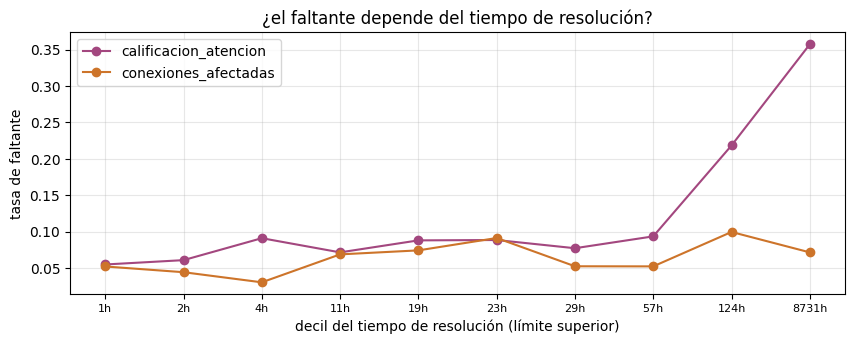

calificación: falta en 5.5% del decil más rápido y en 35.7% del más lento


In [9]:
### 1.8 Mecanismo de cada faltante
# Variables observadas contra las que se contrasta cada indicador de faltante.
aud["horas_obs"] = np.where(aud.tiempo_resolucion_minutos >= 0, aud.tiempo_resolucion_minutos / 60, np.nan)
aud["distancia_km"] = np.where(aud.distancia_centro_km > UMBRAL_METROS,
                               aud.distancia_centro_km / 1000, aud.distancia_centro_km)
aud["mes"] = aud.fecha_ingreso.dt.month
OBS_NUM = ["horas_obs", "distancia_km", "conexiones_afectadas", "calificacion_atencion"]
OBS_CAT = ["region", "tipo_reclamo", "tipo_complejidad", "ausencia_agua", "baja_presion", "inunda", "mes"]


def contraste_faltante(falta, nombre):
    """MCAR implica que el faltante no depende de nada observado: se contrasta contra cada variable.
    Los niveles con menos de 10 filas quedan fuera del chi²: una celda de 1 fila no lo sostiene."""
    filas = []
    for c in OBS_NUM:
        a, b = aud.loc[falta, c].dropna(), aud.loc[~falta, c].dropna()
        if c == nombre or len(a) < 5:
            continue
        filas.append((c, "Mann-Whitney", f"mediana {a.median():.2f} (falta) vs {b.median():.2f} (no falta)",
                      stats.mannwhitneyu(a, b).pvalue))
    for c in OBS_CAT:
        cuenta = aud[c].value_counts()
        ok = ~aud[c].isin(cuenta[cuenta < 10].index)
        tab = pd.crosstab(aud.loc[ok, c], falta[ok])
        tasa = falta[ok].groupby(aud.loc[ok, c]).mean()
        nota = f" ({(~ok).sum()} filas de niveles raros fuera)" if (~ok).any() else ""
        filas.append((c, "chi²", f"tasa de faltante por nivel: {tasa.min():.1%} – {tasa.max():.1%}{nota}",
                      stats.chi2_contingency(tab)[1]))
    out = pd.DataFrame(filas, columns=["variable observada", "contraste", "efecto", "p"])
    out["p (Bonferroni)"] = (out["p"] * len(out)).clip(upper=1)
    print(f"── {nombre}: {falta.sum()} faltantes ({falta.mean():.1%}) · tasa global {falta.mean():.1%}")
    display(out)
    return out


falta_conex = aud.conexiones_afectadas.isna()
c_conex = contraste_faltante(falta_conex, "conexiones_afectadas")

falta_calif = aud.calificacion_atencion.isna()
c_calif = contraste_faltante(falta_calif, "calificacion_atencion")

deciles = pd.qcut(aud.horas_obs, 10)
tasa_calif = falta_calif.groupby(deciles, observed=True).mean()
tasa_conex = falta_conex.groupby(deciles, observed=True).mean()
fig, eje = plt.subplots(figsize=(10, 3.4))
eje.plot(range(10), tasa_calif.values, "o-", color=VIOLETA, label="calificacion_atencion")
eje.plot(range(10), tasa_conex.values, "o-", color=NARANJA, label="conexiones_afectadas")
eje.set_xticks(range(10), [f"{iv.right:.0f}h" for iv in tasa_calif.index], fontsize=8)
eje.set_xlabel("decil del tiempo de resolución (límite superior)"); eje.set_ylabel("tasa de faltante")
eje.set_title("¿el faltante depende del tiempo de resolución?"); eje.legend(); plt.show()
print(f"calificación: falta en {tasa_calif.iloc[0]:.1%} del decil más rápido y en {tasa_calif.iloc[-1]:.1%} del más lento")

In [10]:
# Faltantes de la respuesta y de las columnas de la orden de trabajo: se contrastan contra la estructura.
print("── respuesta (tiempo -1 / fechas 1900) contra estado_resuelto:")
display(pd.crosstab(df.estado_resuelto, centinela_tiempo, colnames=["tiempo sin valor"]))

sin_orden = df.tipo_orden == "S/DATOS"
print("── tipo_orden 'S/DATOS' contra id_centro_tecnico == -1 y grupo_orden:")
display(pd.crosstab(sin_orden, df.id_centro_tecnico == -1, rownames=["tipo_orden S/DATOS"],
                    colnames=["centro -1"]))
print(f"grupo_orden es 'S/DATOS' exactamente en las mismas filas: "
      f"{((df.grupo_orden == 'S/DATOS') == sin_orden).all()}")
c_orden = contraste_faltante(pd.Series(sin_orden.to_numpy(), index=aud.index), "tipo_orden (S/DATOS)")

negativo_real = pd.Series(((t_min < 0) & ~es_1900_v).to_numpy(), index=aud.index)
print("── tiempo negativo (no es faltante, pero la fila pierde la respuesta):")
c_neg = contraste_faltante(negativo_real, "tiempo negativo")

── respuesta (tiempo -1 / fechas 1900) contra estado_resuelto:


tiempo sin valor,False,True
estado_resuelto,,
Resuelto Improcedente,447,0
Resuelto Procedente,3508,0
SIN DATOS,0,9


── tipo_orden 'S/DATOS' contra id_centro_tecnico == -1 y grupo_orden:


centro -1,False,True
tipo_orden S/DATOS,,
False,3645,9
True,0,310


grupo_orden es 'S/DATOS' exactamente en las mismas filas: True
── tipo_orden (S/DATOS): 310 faltantes (7.8%) · tasa global 7.8%


,variable observada,contraste,efecto,p,p (Bonferroni)
0,horas_obs,Mann-Whitney,mediana 12.31 (falta) vs 19.07 (no falta),4.5313e-12,4.9844e-11
1,distancia_km,Mann-Whitney,mediana 26.86 (falta) vs 28.00 (no falta),3.9924e-02,4.3917e-01
2,conexiones_afectadas,Mann-Whitney,mediana 32.00 (falta) vs 27.00 (no falta),2.4806e-03,2.7287e-02
3,calificacion_atencion,Mann-Whitney,mediana 4.60 (falta) vs 4.30 (no falta),3.5713e-05,3.9284e-04
4,region,chi²,tasa de faltante por nivel: 1.7% – 15.5%,1.2359e-09,1.3595e-08
5,tipo_reclamo,chi²,tasa de faltante por nivel: 2.1% – 14.6% (1 fi...,3.9369e-39,4.3306e-38
6,tipo_complejidad,chi²,tasa de faltante por nivel: 5.4% – 9.0% (4 fil...,5.1505e-02,5.6656e-01
7,ausencia_agua,chi²,tasa de faltante por nivel: 3.6% – 14.1%,6.1806e-33,6.7987e-32
8,baja_presion,chi²,tasa de faltante por nivel: 3.5% – 8.4%,2.4618e-04,2.7080e-03
9,inunda,chi²,tasa de faltante por nivel: 3.8% – 8.0%,4.8725e-02,5.3597e-01


── tiempo negativo (no es faltante, pero la fila pierde la respuesta):


── tiempo negativo: 322 faltantes (8.1%) · tasa global 8.1%

,variable observada,contraste,efecto,p,p (Bonferroni)
0,distancia_km,Mann-Whitney,mediana 24.87 (falta) vs 27.95 (no falta),7.8241e-01,1.0000e+00
1,conexiones_afectadas,Mann-Whitney,mediana 30.00 (falta) vs 27.00 (no falta),1.6393e-01,1.0000e+00
2,calificacion_atencion,Mann-Whitney,mediana 4.30 (falta) vs 4.40 (no falta),5.3753e-01,1.0000e+00
3,region,chi²,tasa de faltante por nivel: 2.5% – 13.4%,3.3576e-05,3.3576e-04
4,tipo_reclamo,chi²,tasa de faltante por nivel: 0.0% – 13.9% (1 fi...,4.4322e-13,4.4322e-12
5,tipo_complejidad,chi²,tasa de faltante por nivel: 4.6% – 9.0% (4 fil...,2.0499e-02,2.0499e-01
6,ausencia_agua,chi²,tasa de faltante por nivel: 5.4% – 12.3%,1.0186e-14,1.0186e-13
7,baja_presion,chi²,tasa de faltante por nivel: 5.2% – 8.5%,1.4641e-02,1.4641e-01
8,inunda,chi²,tasa de faltante por nivel: 4.3% – 8.3%,6.9221e-02,6.9221e-01
9,mes,chi²,tasa de faltante por nivel: 6.2% – 10.2%,8.0217e-01,1.0000e+00


In [11]:
# Resumen del diagnóstico: el contraste decide el mecanismo y el mecanismo decide el tratamiento.
def p_min(tabla, excluir=()):
    t = tabla[~tabla["variable observada"].isin(excluir)]
    return f"p mín. (Bonf.) = {t['p (Bonferroni)'].min():.3g} ({t.loc[t['p (Bonferroni)'].idxmin(), 'variable observada']})"

mecanismos = pd.DataFrame([
    ("conexiones_afectadas", int(falta_conex.sum()), "MCAR (no rechazado)",
     p_min(c_conex), "imputar mediana DENTRO del pipeline"),
    ("calificacion_atencion", int(falta_calif.sum()), "MAR en el tiempo de resolución; MNAR no descartable",
     p_min(c_calif) + f"; tasa {tasa_calif.iloc[0]:.0%} → {tasa_calif.iloc[-1]:.0%} por decil de horas",
     "excluida por disponibilidad (posterior); en el flujo contaminado, mediana en el pipeline"),
    ("tiempo_resolucion / fechas de resolución", int(centinela_tiempo.sum()), "estructural (MAR en estado_resuelto)",
     "coincide 100 % con estado_resuelto = 'SIN DATOS'", "sin respuesta → la fila sale del conjunto"),
    ("tipo_orden / grupo_orden / id_centro_tecnico", int(sin_orden.sum()), "estructural: reclamo sin orden de trabajo",
     p_min(c_orden), "excluidas por disponibilidad; en el flujo contaminado, nivel propio"),
    ("estado_resuelto", int((df.estado_resuelto == "SIN DATOS").sum()), "estructural (mismas filas que la respuesta)",
     "mismas 9 filas que las fechas 1900", "salen con la respuesta"),
], columns=["Variable", "Faltantes", "Mecanismo", "Contraste que lo sostiene", "Tratamiento"])
with pd.option_context("display.max_colwidth", None):
    display(mecanismos)

,Variable,Faltantes,Mecanismo,Contraste que lo sostiene,Tratamiento
0,conexiones_afectadas,255,MCAR (no rechazado),p mín. (Bonf.) = 0.0741 (horas_obs),imputar mediana DENTRO del pipeline
1,calificacion_atencion,464,MAR en el tiempo de resolución; MNAR no descartable,p mín. (Bonf.) = 2.74e-36 (horas_obs); tasa 5% → 36% por decil de horas,"excluida por disponibilidad (posterior); en el flujo contaminado, mediana en el pipeline"
2,tiempo_resolucion / fechas de resolución,9,estructural (MAR en estado_resuelto),coincide 100 % con estado_resuelto = 'SIN DATOS',sin respuesta → la fila sale del conjunto
3,tipo_orden / grupo_orden / id_centro_tecnico,310,estructural: reclamo sin orden de trabajo,p mín. (Bonf.) = 4.33e-38 (tipo_reclamo),"excluidas por disponibilidad; en el flujo contaminado, nivel propio"
4,estado_resuelto,9,estructural (mismas filas que la respuesta),mismas 9 filas que las fechas 1900,salen con la respuesta


,Paso,Filas,Comentario
0,Tabla unida,3964,
1,Distancia en metros → km,3964,24 valores ÷ 1000; no cambia filas
2,Sin reingresos duplicados,3932,−32 copias
3,Sin resolución registrada,3923,−9: no hay tiempo que comparar con el plazo
4,Sin tiempos negativos,3604,"−319: resuelto antes de ingresar, respuesta im..."


plazo comprometido = 48 h → incumplen 851 de 3,604 reclamos: prevalencia = 23.6% (desbalance 76% / 24%)


,horas,log(1 + horas)
media,66.6110,2.7934
mediana,18.7167,2.9815
asimetría,16.4720,0.3535
curtosis en exceso,389.6833,-0.2364
percentil 99,812.9270,6.7018


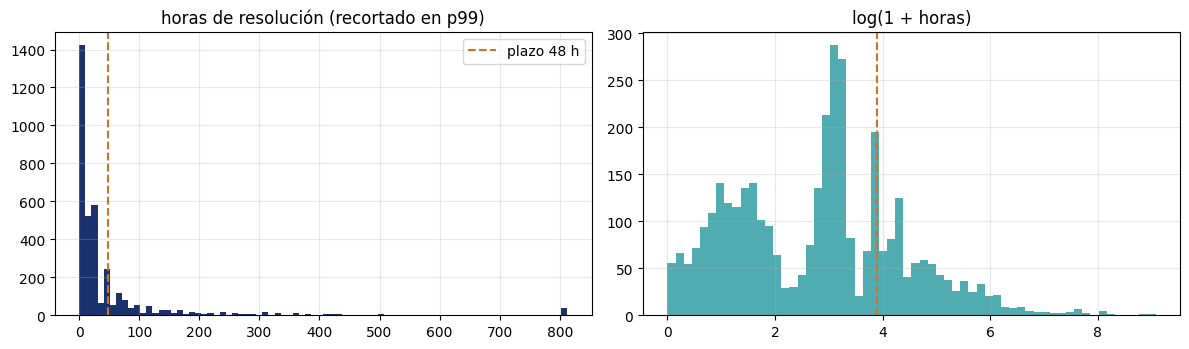

In [12]:
### 1.9 Tabla de trabajo y respuesta binaria
def construir_respuesta(tabla):
    """Elimina las filas sin respuesta posible y construye horas e incumplimiento."""
    sin_resolucion = (tabla.fecha_resuelto_visita.dt.year == 1900) | (tabla.estado_resuelto == "SIN DATOS")
    negativo = (tabla.tiempo_resolucion_minutos < 0) & ~sin_resolucion
    out = tabla.loc[~sin_resolucion & ~negativo].copy()
    out["horas_resolucion"] = out.tiempo_resolucion_minutos / 60
    out["incumple"] = (out.horas_resolucion > PLAZO_HORAS).astype(int)
    return out.reset_index(drop=True), int(sin_resolucion.sum()), int(negativo.sum())


trabajo = df.copy()
en_metros = trabajo.distancia_centro_km > UMBRAL_METROS
trabajo.loc[en_metros, "distancia_centro_km"] = trabajo.loc[en_metros, "distancia_centro_km"] / 1000
con_reingresos = trabajo.copy()                         # se usa en la sección 7
trabajo = trabajo.drop_duplicates(COLS_SIN_ID, keep="first")
n_dedup = len(trabajo)
trabajo, n_sin_res, n_neg = construir_respuesta(trabajo)
con_reingresos, _, _ = construir_respuesta(con_reingresos)

display(pd.DataFrame([
    ("Tabla unida", len(df), ""),
    ("Distancia en metros → km", len(df), f"{en_metros.sum()} valores ÷ 1000; no cambia filas"),
    ("Sin reingresos duplicados", n_dedup, f"−{len(df) - n_dedup} copias"),
    ("Sin resolución registrada", n_dedup - n_sin_res, f"−{n_sin_res}: no hay tiempo que comparar con el plazo"),
    ("Sin tiempos negativos", len(trabajo), f"−{n_neg}: resuelto antes de ingresar, respuesta imposible"),
], columns=["Paso", "Filas", "Comentario"]))

prevalencia = trabajo.incumple.mean()
print(f"plazo comprometido = {PLAZO_HORAS} h → incumplen {trabajo.incumple.sum():,} de {len(trabajo):,} "
      f"reclamos: prevalencia = {prevalencia:.1%} (desbalance {1 - prevalencia:.0%} / {prevalencia:.0%})")

h = trabajo.horas_resolucion
forma = pd.DataFrame({
    "horas": [h.mean(), h.median(), stats.skew(h), stats.kurtosis(h), h.quantile(0.99)],
    "log(1 + horas)": [np.log1p(h).mean(), np.log1p(h).median(), stats.skew(np.log1p(h)),
                       stats.kurtosis(np.log1p(h)), np.log1p(h).quantile(0.99)],
}, index=["media", "mediana", "asimetría", "curtosis en exceso", "percentil 99"])
display(forma)

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
ejes[0].hist(h.clip(upper=h.quantile(0.99)), bins=80, color=AZUL)
ejes[0].axvline(PLAZO_HORAS, color=NARANJA, ls="--", label=f"plazo {PLAZO_HORAS} h")
ejes[0].set_title("horas de resolución (recortado en p99)"); ejes[0].legend()
ejes[1].hist(np.log1p(h), bins=60, color=TURQUESA)
ejes[1].axvline(np.log1p(PLAZO_HORAS), color=NARANJA, ls="--")
ejes[1].set_title("log(1 + horas)")
plt.tight_layout(); plt.show()

**Trazabilidad de la unión**

| Paso | Filas | Comentario |
|---|---|---|
| Archivo de OSE, crudo | | |
| Complemento de la cátedra | | |
| Tras el filtro por identificador | | |
| Tras la unión | | |

**Mecanismo de los faltantes**

| Variable | Faltantes | Mecanismo | Contraste que lo sostiene | Tratamiento que se deriva |
|---|---|---|---|---|

**Informe de hallazgos**

| Defecto | Evidencia que lo produce | Decisión propuesta |
|---|---|---|

**Construcción de la respuesta binaria:**

## 2. Preparación dentro de un pipeline

Ejecutar las decisiones de la sección 1 dentro de un `Pipeline` con `ColumnTransformer`. **Ninguna transformación que aprenda algo de los datos** —una media, una mediana, una escala, una lista de categorías— **puede ubicarse fuera del pipeline.** La limpieza determinista, que no estima nada a partir de la muestra, puede hacerse antes y no se penaliza.

Declarar explícitamente **qué columnas quedan fuera de la matriz de entrada y por qué**. Cada exclusión se justifica una por una, y la justificación de disponibilidad en el momento en que el reclamo ingresa es distinta de la justificación por desempeño: si una columna se excluye por las dos razones, corresponde decir cuál manda.

In [13]:
### Limpieza determinista adicional: calendario del ingreso (se conoce al ingresar el reclamo)
FRANJAS = ["00-06 madrugada", "06-12 mañana", "12-18 tarde", "18-24 noche"]
DIAS = ["1 lunes", "2 martes", "3 miércoles", "4 jueves", "5 viernes", "6 sábado", "7 domingo"]


def agregar_calendario(tabla):
    tabla = tabla.copy()
    tabla["franja_ingreso"] = pd.cut(tabla.fecha_ingreso.dt.hour, [0, 6, 12, 18, 24], right=False,
                                     labels=FRANJAS).astype(str)
    tabla["dia_semana"] = tabla.fecha_ingreso.dt.dayofweek.map(dict(enumerate(DIAS)))
    tabla["mes"] = tabla.fecha_ingreso.dt.month.map("{:02d}".format)
    tabla["centro_tecnico"] = tabla.id_centro_tecnico.astype(int).astype(str).replace({"-1": "SIN_CENTRO"})
    return tabla


trabajo = agregar_calendario(trabajo)
con_reingresos = agregar_calendario(con_reingresos)
print("regiones por departamento (máximo):", trabajo.groupby("departamento").region.nunique().max(),
      "→ region es función de departamento")

### Matriz de entrada
NUMERICAS = ["distancia_centro_km", "conexiones_afectadas"]
CATEGORICAS = ["departamento", "tipo_reclamo", "tipo_complejidad", "ausencia_agua", "baja_presion",
               "inunda", "franja_ingreso", "dia_semana", "mes"]
ENTRADA_HONESTA = NUMERICAS + CATEGORICAS
POSTERIORES_NUM = ["calificacion_atencion"]
POSTERIORES_CAT = ["estado_resuelto", "tipo_orden", "grupo_orden", "centro_tecnico"]

excluidas = pd.DataFrame([
    ("id", "identificador pseudonimizado: no describe al reclamo", "ninguna (no es atributo)"),
    ("año, fecha_foto", "constantes en toda la tabla", "desempeño"),
    ("fecha_ingreso", "reemplazada por franja, día y mes (limpieza determinista)", "desempeño"),
    ("region", "función exacta de departamento: colinealidad perfecta en MCO", "desempeño"),
    ("tiempo_resolucion_minutos, horas_resolucion, incumple", "son la respuesta", "disponibilidad"),
    ("fecha_resuelto_visita, fecha_resuelto_sistema", "se conocen al resolver; definen la respuesta", "disponibilidad"),
    ("estado_resuelto", "se asigna al cerrar el reclamo", "disponibilidad"),
    ("tipo_orden, grupo_orden", "la orden de trabajo se genera después del ingreso", "disponibilidad"),
    ("id_centro_tecnico", "metadatos: 'centro técnico que resolvió'",
     f"disponibilidad (manda sobre sus {trabajo.centro_tecnico.nunique()} niveles)"),
    ("calificacion_atencion", "la califica el cliente después de la atención", "disponibilidad"),
], columns=["Columna", "Razón de la exclusión", "¿Disponibilidad o desempeño?"])
with pd.option_context("display.max_colwidth", None):
    display(excluidas)

regiones por departamento (máximo): 1 → region es función de departamento


,Columna,Razón de la exclusión,¿Disponibilidad o desempeño?
0,id,identificador pseudonimizado: no describe al reclamo,ninguna (no es atributo)
1,"año, fecha_foto",constantes en toda la tabla,desempeño
2,fecha_ingreso,"reemplazada por franja, día y mes (limpieza determinista)",desempeño
3,region,función exacta de departamento: colinealidad perfecta en MCO,desempeño
4,"tiempo_resolucion_minutos, horas_resolucion, incumple",son la respuesta,disponibilidad
5,"fecha_resuelto_visita, fecha_resuelto_sistema",se conocen al resolver; definen la respuesta,disponibilidad
6,estado_resuelto,se asigna al cerrar el reclamo,disponibilidad
7,"tipo_orden, grupo_orden",la orden de trabajo se genera después del ingreso,disponibilidad
8,id_centro_tecnico,metadatos: 'centro técnico que resolvió',disponibilidad (manda sobre sus 83 niveles)
9,calificacion_atencion,la califica el cliente después de la atención,disponibilidad


In [14]:
### El preprocesamiento: todo lo que aprende de la muestra vive acá adentro
def preprocesador(numericas, categoricas, escalar=True):
    pasos_num = [("imputar", SimpleImputer(strategy="median"))]
    if escalar:
        pasos_num.append(("escalar", StandardScaler()))
    pasos_cat = [
        ("imputar", SimpleImputer(strategy="constant", fill_value="SIN_DATO")),
        ("onehot", OneHotEncoder(drop="first", min_frequency=10, handle_unknown="infrequent_if_exist",
                                 sparse_output=False)),
    ]
    return ColumnTransformer([("num", Pipeline(pasos_num), numericas),
                              ("cat", Pipeline(pasos_cat), categoricas)])


X = trabajo[ENTRADA_HONESTA]
y_horas = trabajo.horas_resolucion.to_numpy()
y_inc = trabajo.incumple.to_numpy()

prep_demo = preprocesador(NUMERICAS, CATEGORICAS).fit(X)
ohe = prep_demo.named_transformers_["cat"].named_steps["onehot"]
print(f"{len(ENTRADA_HONESTA)} columnas de entrada → {len(prep_demo.get_feature_names_out())} tras one-hot")
print("lo que el pipeline estima de la muestra (y re-estima en cada fold):")
print("  medianas de imputación:", {c: round(float(v), 2) for c, v in zip(NUMERICAS, prep_demo.named_transformers_["num"]["imputar"].statistics_)})
print("  medias del escalado:   ", {c: round(float(v), 2) for c, v in zip(NUMERICAS, prep_demo.named_transformers_["num"]["escalar"].mean_)})
print("  categorías agrupadas por infrecuentes:",
      {c: list(inf) for c, inf in zip(CATEGORICAS, ohe.infrequent_categories_) if inf is not None})
print("  nivel de referencia (drop='first'):",
      {c: ohe.categories_[i][ohe.drop_idx_[i]] for i, c in enumerate(CATEGORICAS)})
prep_demo

11 columnas de entrada → 55 tras one-hot
lo que el pipeline estima de la muestra (y re-estima en cada fold):
  medianas de imputación: {'distancia_centro_km': 28.44, 'conexiones_afectadas': 27.0}
  medias del escalado:    {'distancia_centro_km': 33.12, 'conexiones_afectadas': 42.95}
  categorías agrupadas por infrecuentes: {'tipo_reclamo': ['Solicitud Camion Cisterna'], 'tipo_complejidad': ['Escritorio Técnico']}
  nivel de referencia (drop='first'): {'departamento': 'ARTIGAS', 'tipo_reclamo': 'CA  Problema de Calidad del Agua', 'tipo_complejidad': 'Con corte de pavimento', 'ausencia_agua': 'AUSENCIA AGUA', 'baja_presion': 'BAJA PRESION', 'inunda': 'INUNDA', 'franja_ingreso': '00-06 madrugada', 'dia_semana': '1 lunes', 'mes': '01'}


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


**Columnas excluidas de la matriz de entrada**

| Columna | Razón de la exclusión | ¿Disponibilidad o desempeño? |
|---|---|---|

**Qué queda fuera del pipeline y por qué es determinista:**

## 3. Línea base

**Antes de ajustar el primer modelo.** Para la regresión, predecir siempre la media de la respuesta; para la clasificación, la prevalencia observada.

En regresión, al menos una de las métricas reportadas tiene que estar **en las unidades de la respuesta**, porque es la única forma de que la comparación se lea como una mejora operativa y no como un número abstracto.

Una línea base que se calcula y no se vuelve a citar no cuenta: **las secciones 4 a 13 la usan**.

In [15]:
def _rmsle(y, p):
    return np.sqrt(np.mean((np.log1p(y) - np.log1p(np.clip(p, 0, None))) ** 2))


ESCORES_REG = {"MAE (h)": "neg_mean_absolute_error", "RMSE (h)": "neg_root_mean_squared_error",
               "MedAE (h)": "neg_median_absolute_error", "R²": "r2",
               "RMSLE": make_scorer(_rmsle, greater_is_better=False)}
ESCORES_CLF = {"AUC-ROC": "roc_auc", "AP (PR-AUC)": "average_precision",
               "Brier": "neg_brier_score", "log-loss": "neg_log_loss"}
MAYOR_ES_MEJOR = {"R²", "AUC-ROC", "AP (PR-AUC)"}
RES_REG, RES_CLF = {}, {}
BASE_REG, BASE_CLF = "Línea base: media", "Línea base: prevalencia"


def evaluar(modelo, X_, y_, nombre, tipo):
    """VC que envuelve al pipeline completo; guarda las métricas de cada fold."""
    cv, escores, res = (CV_REG, ESCORES_REG, RES_REG) if tipo == "reg" else (CV_CLF, ESCORES_CLF, RES_CLF)
    r = cross_validate(modelo, X_, y_, cv=cv, scoring=escores, n_jobs=-1)
    res[nombre] = {k: r[f"test_{k}"] * (1 if k in MAYOR_ES_MEJOR else -1) for k in escores}
    return res[nombre]


def tabla(tipo, nombres=None):
    """Media ± desvío de cada métrica, y la diferencia contra la línea base."""
    res, base, clave = (RES_REG, BASE_REG, "MAE (h)") if tipo == "reg" else (RES_CLF, BASE_CLF, "AP (PR-AUC)")
    filas = {}
    for n, m in res.items():
        if nombres is not None and n not in nombres and n != base:
            continue
        filas[n] = {k: f"{v.mean():.3f} ± {v.std(ddof=1):.3f}" for k, v in m.items()}
        dif = m[clave] - res[base][clave]
        filas[n][f"Δ {clave} vs base"] = f"{dif.mean():+.3f} ± {dif.std(ddof=1):.3f}"
    return pd.DataFrame(filas).T


_ = evaluar(DummyRegressor(strategy="mean"), X, y_horas, BASE_REG, "reg")
_ = evaluar(DummyClassifier(strategy="prior"), X, y_inc, BASE_CLF, "clf")
print(f"Regresión — {K_FOLDS} folds, respuesta en horas")
display(tabla("reg"))
print(f"Clasificación — {K_FOLDS} folds estratificados, prevalencia {prevalencia:.1%}")
display(tabla("clf"))

LB = {k: v.mean() for k, v in RES_REG[BASE_REG].items()} | {k: v.mean() for k, v in RES_CLF[BASE_CLF].items()}
print(f"Predecir siempre la media ({y_horas.mean():.1f} h) erra en promedio {LB['MAE (h)']:.1f} h por reclamo "
      f"(RMSE {LB['RMSE (h)']:.1f} h). Predecir siempre la prevalencia da AUC {LB['AUC-ROC']:.2f} "
      f"y AP {LB['AP (PR-AUC)']:.3f} (= prevalencia).")

Regresión — 5 folds, respuesta en horas


,MAE (h),RMSE (h),MedAE (h),R²,RMSLE,Δ MAE (h) vs base
Línea base: media,82.901 ± 8.171,259.330 ± 108.334,56.408 ± 2.771,-0.002 ± 0.001,2.118 ± 0.030,+0.000 ± 0.000


Clasificación — 5 folds estratificados, prevalencia 23.6%


,AUC-ROC,AP (PR-AUC),Brier,log-loss,Δ AP (PR-AUC) vs base
Línea base: prevalencia,0.500 ± 0.000,0.236 ± 0.001,0.180 ± 0.000,0.547 ± 0.001,+0.000 ± 0.000


Predecir siempre la media (66.6 h) erra en promedio 82.9 h por reclamo (RMSE 259.3 h). Predecir siempre la prevalencia da AUC 0.50 y AP 0.236 (= prevalencia).


**Línea base de la regresión:**

**Línea base de la clasificación:**

**Declaración:** todo número reportado a partir de acá se informa contra estas dos líneas base.

## 4. Regresión sobre el tiempo de resolución

Ajustar una regresión lineal por mínimos cuadrados sobre la preparación de la sección 2.

La forma de la distribución de la respuesta, medida en la sección 1, condiciona si conviene modelarla directamente o transformada. **La decisión es del grupo y se deriva de esa medición**, no de la costumbre; si se transforma, el resultado tiene que poder volver a leerse en horas.

**Leer los coeficientes en las unidades del caso**: cuánto agrega un kilómetro más de distancia, cuánto una conexión afectada más. Los coeficientes se interpretan, no se listan.

,MAE (h),RMSE (h),MedAE (h),R²,RMSLE,Δ MAE (h) vs base
Línea base: media,82.901 ± 8.171,259.330 ± 108.334,56.408 ± 2.771,-0.002 ± 0.001,2.118 ± 0.030,+0.000 ± 0.000
MCO sobre horas,89.461 ± 6.915,252.624 ± 105.645,52.408 ± 4.241,0.050 ± 0.028,2.110 ± 0.077,+6.560 ± 5.040
MCO sobre log(1 + horas),57.863 ± 10.474,259.318 ± 108.311,12.344 ± 0.819,-0.002 ± 0.008,1.351 ± 0.031,-25.038 ± 2.326


MCO sobre horas: 16.4% de predicciones negativas (horas imposibles)
asimetría de los residuos: 15.9 (horas) vs 0.34 (log)


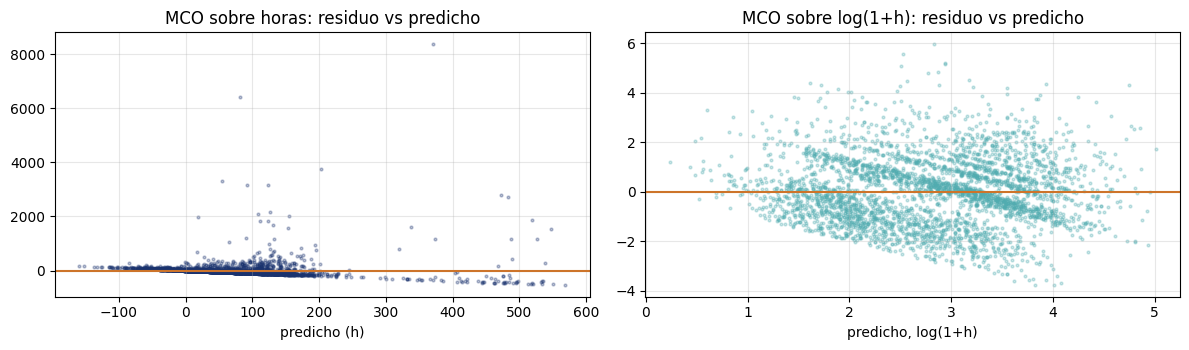

In [16]:
def pipeline_reg(estimador, numericas=NUMERICAS, categoricas=CATEGORICAS, escalar=True, log=True):
    pipe = Pipeline([("prep", preprocesador(numericas, categoricas, escalar)), ("modelo", estimador)])
    if not log:
        return pipe
    # se ajusta sobre log(1 + horas) y se predice de vuelta en horas: todas las métricas quedan en horas
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)


# La sección 1 midió asimetría 16 en horas y ~0,4 en log(1 + horas): se comparan las dos opciones.
ols_horas = pipeline_reg(LinearRegression(), log=False)
ols_log = pipeline_reg(LinearRegression())
evaluar(ols_horas, X, y_horas, "MCO sobre horas", "reg")
evaluar(ols_log, X, y_horas, "MCO sobre log(1 + horas)", "reg")
display(tabla("reg"))

pred_horas = cross_val_predict(ols_horas, X, y_horas, cv=CV_REG)
pred_log = cross_val_predict(ols_log, X, y_horas, cv=CV_REG)
print(f"MCO sobre horas: {(pred_horas < 0).mean():.1%} de predicciones negativas (horas imposibles)")
res_h, res_l = y_horas - pred_horas, np.log1p(y_horas) - np.log1p(pred_log)
print(f"asimetría de los residuos: {stats.skew(res_h):.1f} (horas) vs {stats.skew(res_l):.2f} (log)")

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
ejes[0].scatter(pred_horas, res_h, s=4, alpha=0.3, color=AZUL)
ejes[0].set_title("MCO sobre horas: residuo vs predicho"); ejes[0].set_xlabel("predicho (h)")
ejes[1].scatter(np.log1p(pred_log), res_l, s=4, alpha=0.3, color=TURQUESA)
ejes[1].set_title("MCO sobre log(1+h): residuo vs predicho"); ejes[1].set_xlabel("predicho, log(1+h)")
for e in ejes:
    e.axhline(0, color=NARANJA)
plt.tight_layout(); plt.show()

In [17]:
### Coeficientes en unidades del caso (modelo en log: efectos multiplicativos sobre 1 + horas)
def separar(nombre):
    """'cat__tipo_reclamo_RP Denuncia' → ('tipo_reclamo', 'RP Denuncia')."""
    cuerpo = nombre.split("__", 1)[1]
    var = max((c for c in CATEGORICAS + POSTERIORES_CAT if cuerpo.startswith(c + "_")), key=len)
    return var, cuerpo[len(var) + 1:]


ols_log.fit(X, y_horas)
pipe = ols_log.regressor_
nombres = pipe.named_steps["prep"].get_feature_names_out()
coef = pd.Series(pipe.named_steps["modelo"].coef_, index=nombres)
escala = pipe.named_steps["prep"].named_transformers_["num"]["escalar"].scale_
h_tipico = np.median(y_horas)
PASOS = {"distancia_centro_km": (1, 10, "km"), "conexiones_afectadas": (1, 10, "conexiones")}

print(f"reclamo típico: {h_tipico:.1f} h (mediana)\n")
for var, s in zip(NUMERICAS, escala):
    b = coef[f"num__{var}"] / s               # efecto por unidad original, en log(1 + horas)
    uno, diez, unidad = PASOS[var]
    for paso in (uno, diez):
        f = np.exp(b * paso)
        print(f"{var}: +{paso} {unidad} → (1 + horas) × {f:.4f} ({f - 1:+.2%}); "
              f"en el reclamo típico, {(1 + h_tipico) * (f - 1):+.2f} h")
    print()

ohe_fit = pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
referencia = {c: ohe_fit.categories_[i][ohe_fit.drop_idx_[i]] for i, c in enumerate(CATEGORICAS)}
cat = coef[coef.index.str.startswith("cat__")]
filas = []
for n, b in cat.items():
    var, nivel = separar(n)
    filas.append((var, nivel, referencia[var], b, np.exp(b), (1 + h_tipico) * (np.exp(b) - 1)))
tabla_cat = pd.DataFrame(filas, columns=["variable", "nivel", "referencia", "β", "× (1 + horas)", "Δ h en el típico"])
print("los 15 niveles con mayor efecto (en valor absoluto):")
display(tabla_cat.reindex(tabla_cat["β"].abs().sort_values(ascending=False).index).head(15))
print(f"media de lo predicho {pred_log.mean():.1f} h vs media observada {y_horas.mean():.1f} h: volver de log "
      "con expm1 da algo cercano a la mediana condicional, no a la media.")

reclamo típico: 18.7 h (mediana)

distancia_centro_km: +1 km → (1 + horas) × 1.0176 (+1.76%); en el reclamo típico, +0.35 h
distancia_centro_km: +10 km → (1 + horas) × 1.1902 (+19.02%); en el reclamo típico, +3.75 h

conexiones_afectadas: +1 conexiones → (1 + horas) × 1.0022 (+0.22%); en el reclamo típico, +0.04 h
conexiones_afectadas: +10 conexiones → (1 + horas) × 1.0218 (+2.18%); en el reclamo típico, +0.43 h

los 15 niveles con mayor efecto (en valor absoluto):


,variable,nivel,referencia,β,× (1 + horas),Δ h en el típico
30,ausencia_agua,CON AGUA,AUSENCIA AGUA,0.9577,2.6058,31.6612
8,departamento,MONTEVIDEO,ARTIGAS,0.9394,2.5584,30.7266
17,departamento,TREINTA Y TRES,ARTIGAS,-0.8559,0.4249,-11.3388
23,tipo_reclamo,RS Reposición y Señalización,CA Problema de Calidad del Agua,0.7645,2.1479,22.6326
6,departamento,LAVALLEJA,ARTIGAS,-0.5296,0.5889,-8.1063
35,franja_ingreso,18-24 noche,00-06 madrugada,0.4799,1.6159,12.1430
5,departamento,FLORIDA,ARTIGAS,-0.4581,0.6325,-7.2462
41,dia_semana,7 domingo,1 lunes,0.4451,1.5606,11.0530
15,departamento,SORIANO,ARTIGAS,0.4442,1.5593,11.0276
40,dia_semana,6 sábado,1 lunes,0.4072,1.5026,9.9090


media de lo predicho 21.8 h vs media observada 66.6 h: volver de log con expm1 da algo cercano a la mediana condicional, no a la media.


**Decisión sobre la transformación de la respuesta, y la medición que la sostiene:**

**Interpretación de los coeficientes:**

**Resultado contra la línea base, también en horas:**

## 5. Regularización: Ridge y Lasso

Ajustar Ridge y Lasso sobre exactamente la misma preparación y comparar los tres modelos sobre la misma validación.

- El $\lambda$ **se elige por validación cruzada**, nunca a mano.
- **La grilla se declara** en el notebook y es logarítmica. Si el $\lambda$ elegido cae en un extremo, el óptimo está afuera: corresponde decirlo y ampliarla.
- **Interpretar qué variables anula Lasso.** La lista de coeficientes en cero es el resultado de esta sección, no una salida que se imprime y se deja.

Una conclusión negativa bien argumentada es una respuesta correcta.

In [18]:
GRILLA_RIDGE = np.logspace(-3, 4, 29)     # λ de Ridge
GRILLA_LASSO = np.logspace(-5, 0, 26)     # λ de Lasso
ESCORE_SELECCION = ESCORES_REG["RMSLE"]   # la pérdida en la escala en que se ajusta el modelo


def elegir_lambda(estimador, grilla, nombre, ampliaciones=2):
    """GridSearchCV; si el óptimo cae en un borde, amplía tres décadas hacia ese lado."""
    for intento in range(ampliaciones + 1):
        gs = GridSearchCV(pipeline_reg(estimador), {"regressor__modelo__alpha": grilla},
                          cv=CV_REG, scoring=ESCORE_SELECCION, n_jobs=-1).fit(X, y_horas)
        i = int(np.argmax(gs.cv_results_["mean_test_score"]))
        lo, hi = np.log10(grilla[0]), np.log10(grilla[-1])
        if 0 < i < len(grilla) - 1:
            print(f"{nombre}: λ* = {grilla[i]:.3g}, interior a la grilla [1e{lo:.0f}, 1e{hi:.0f}] "
                  f"({len(grilla)} valores)")
            return gs, grilla
        borde = "inferior" if i == 0 else "superior"
        if intento == ampliaciones:
            print(f"{nombre}: tras {ampliaciones} ampliaciones λ* sigue en el borde {borde} ({grilla[i]:.1e})")
            return gs, grilla
        lo, hi = (lo - 3, hi) if i == 0 else (lo, hi + 3)
        grilla = np.logspace(lo, hi, int(round((hi - lo) * 4)) + 1)
        print(f"{nombre}: λ* cayó en el borde {borde}; se amplía la grilla a [1e{lo:.0f}, 1e{hi:.0f}]")


gs_ridge, GRILLA_RIDGE = elegir_lambda(Ridge(), GRILLA_RIDGE, "Ridge")
gs_lasso, GRILLA_LASSO = elegir_lambda(Lasso(max_iter=50_000), GRILLA_LASSO, "Lasso")

# Misma VC externa que MCO; el λ se re-elige dentro de cada fold (VC anidada).
for est, grilla, nombre in [(Ridge(), GRILLA_RIDGE, "Ridge"), (Lasso(max_iter=50_000), GRILLA_LASSO, "Lasso")]:
    evaluar(GridSearchCV(pipeline_reg(est), {"regressor__modelo__alpha": grilla}, cv=CV_REG,
                         scoring=ESCORE_SELECCION), X, y_horas, f"{nombre} (λ por VC anidada)", "reg")
display(tabla("reg", [BASE_REG, "MCO sobre log(1 + horas)", "Ridge (λ por VC anidada)", "Lasso (λ por VC anidada)"]))

Ridge: λ* = 17.8, interior a la grilla [1e-3, 1e4] (29 valores)


Lasso: λ* = 0.00158, interior a la grilla [1e-5, 1e0] (26 valores)


,MAE (h),RMSE (h),MedAE (h),R²,RMSLE,Δ MAE (h) vs base
Línea base: media,82.901 ± 8.171,259.330 ± 108.334,56.408 ± 2.771,-0.002 ± 0.001,2.118 ± 0.030,+0.000 ± 0.000
MCO sobre log(1 + horas),57.863 ± 10.474,259.318 ± 108.311,12.344 ± 0.819,-0.002 ± 0.008,1.351 ± 0.031,-25.038 ± 2.326
Ridge (λ por VC anidada),57.821 ± 10.454,259.836 ± 108.447,12.231 ± 0.710,-0.006 ± 0.007,1.348 ± 0.030,-25.080 ± 2.312
Lasso (λ por VC anidada),57.849 ± 10.448,259.678 ± 108.196,12.244 ± 0.650,-0.005 ± 0.007,1.350 ± 0.030,-25.052 ± 2.306


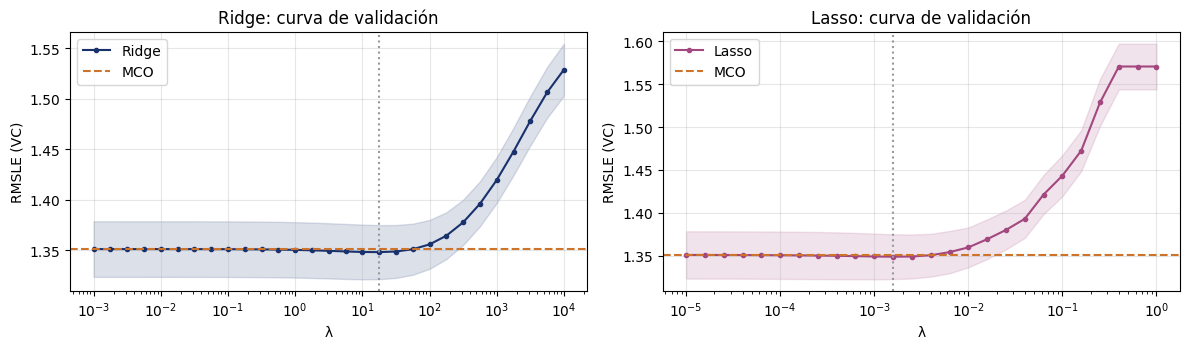

λ* de Lasso = 0.00158: anula 8 de 55 coeficientes


,anulados,columnas,% anulado
variable,,,
tipo_complejidad,2,4,50.0
tipo_reclamo,2,8,25.0
departamento,4,18,22.0
conexiones_afectadas,0,1,0.0
baja_presion,0,1,0.0
ausencia_agua,0,1,0.0
dia_semana,0,6,0.0
franja_ingreso,0,3,0.0
distancia_centro_km,0,1,0.0


,β MCO
columnas anuladas por Lasso,
cat__departamento_CERRO LARGO,-0.1501
cat__departamento_RIO NEGRO,-0.0768
cat__departamento_SAN JOSE,-0.1299
cat__departamento_TACUAREMBO,-0.1183
cat__tipo_reclamo_RE Reclamo por Accion de Empresa,0.0600
cat__tipo_reclamo_infrequent_sklearn,-0.3343
cat__tipo_complejidad_Genérica,-0.0737
cat__tipo_complejidad_infrequent_sklearn,0.3777


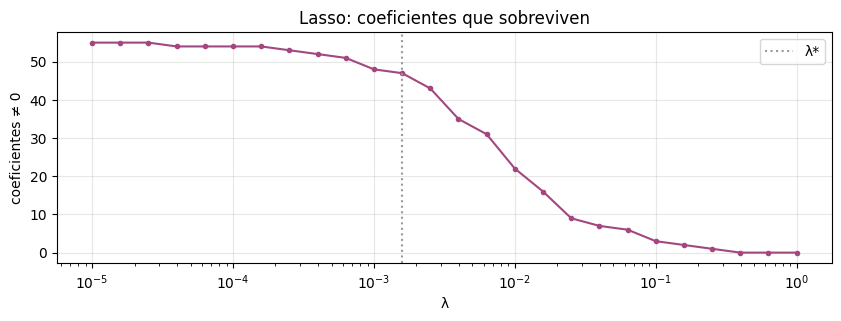

In [19]:
rmsle_mco = RES_REG["MCO sobre log(1 + horas)"]["RMSLE"].mean()
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
for eje, gs, grilla, nombre, color in [(ejes[0], gs_ridge, GRILLA_RIDGE, "Ridge", AZUL),
                                       (ejes[1], gs_lasso, GRILLA_LASSO, "Lasso", VIOLETA)]:
    m, s = -gs.cv_results_["mean_test_score"], gs.cv_results_["std_test_score"]
    eje.semilogx(grilla, m, "o-", ms=3, color=color, label=nombre)
    eje.fill_between(grilla, m - s, m + s, color=color, alpha=0.15)
    eje.axhline(rmsle_mco, color=NARANJA, ls="--", label="MCO")
    eje.axvline(gs.best_params_["regressor__modelo__alpha"], color=GRIS, ls=":")
    eje.set_xlabel("λ"); eje.set_ylabel("RMSLE (VC)"); eje.set_title(f"{nombre}: curva de validación"); eje.legend()
plt.tight_layout(); plt.show()

### Qué anula Lasso
lasso = gs_lasso.best_estimator_.regressor_.named_steps["modelo"]
nombres_l = gs_lasso.best_estimator_.regressor_.named_steps["prep"].get_feature_names_out()
coef_lasso = pd.Series(lasso.coef_, index=nombres_l)
variable = [n.split("__", 1)[1] if n.startswith("num__") else separar(n)[0] for n in nombres_l]
resumen_lasso = (pd.DataFrame({"variable": variable, "anulado": coef_lasso.to_numpy() == 0})
                 .groupby("variable").anulado.agg(anulados="sum", columnas="size"))
resumen_lasso["% anulado"] = (resumen_lasso.anulados / resumen_lasso.columnas * 100).round(0)
print(f"λ* de Lasso = {lasso.alpha:.3g}: anula {int((coef_lasso == 0).sum())} de {len(coef_lasso)} coeficientes")
display(resumen_lasso.sort_values("% anulado", ascending=False))
ceros = coef_lasso[coef_lasso == 0].index
with pd.option_context("display.max_rows", 100):
    display(pd.DataFrame({"β MCO": coef.reindex(ceros).round(4)}).rename_axis("columnas anuladas por Lasso"))

# Trayectoria: cuántos coeficientes sobreviven a medida que crece λ (descriptivo, sobre toda la muestra)
Z = preprocesador(NUMERICAS, CATEGORICAS).fit_transform(X)
vivos = [(Lasso(alpha=a, max_iter=50_000).fit(Z, np.log1p(y_horas)).coef_ != 0).sum() for a in GRILLA_LASSO]
fig, eje = plt.subplots(figsize=(10, 3))
eje.semilogx(GRILLA_LASSO, vivos, "o-", ms=3, color=VIOLETA)
eje.axvline(lasso.alpha, color=GRIS, ls=":", label="λ*")
eje.set_xlabel("λ"); eje.set_ylabel("coeficientes ≠ 0"); eje.set_title("Lasso: coeficientes que sobreviven"); eje.legend()
plt.show()

**Grilla de $\lambda$ declarada:**

**Comparación de los tres modelos:**

**Qué variables anula Lasso, y qué se lee de esa lista:**

**Conclusión sobre si la penalización aporta en este problema, y por qué:**

## 6. Clasificación del incumplimiento del plazo

Ajustar una regresión logística sobre la misma preparación. Reportar la matriz de confusión y el conjunto de métricas que corresponda a la **distribución de la respuesta medida en la sección 1**, argumentando cuál de ellas manda en este problema y por qué. Todo se informa contra la línea base de la sección 3.

In [20]:
def pipeline_clf(estimador, numericas=NUMERICAS, categoricas=CATEGORICAS, escalar=True):
    return Pipeline([("prep", preprocesador(numericas, categoricas, escalar)), ("modelo", estimador)])


# Sin ponderar clases ni remuestrear: las probabilidades quedan calibradas para la sección 9.
logit = pipeline_clf(LogisticRegression(max_iter=5000))
evaluar(logit, X, y_inc, "Logística", "clf")
display(tabla("clf"))

FOLDS_CLF = [va for _, va in CV_CLF.split(X, y_inc)]
proba_logit = cross_val_predict(logit, X, y_inc, cv=CV_CLF, method="predict_proba")[:, 1]
proba_base = cross_val_predict(DummyClassifier(strategy="prior"), X, y_inc, cv=CV_CLF, method="predict_proba")[:, 1]


def metricas_umbral(y, p, umbral):
    pred = (p >= umbral).astype(int)
    return {"exactitud": accuracy_score(y, pred), "exactitud balanceada": balanced_accuracy_score(y, pred),
            "precisión": precision_score(y, pred, zero_division=0), "sensibilidad": recall_score(y, pred),
            "F1": f1_score(y, pred, zero_division=0), "% priorizado": pred.mean()}


def por_fold(p, umbral):
    """Métricas de umbral en cada fold de validación (predicciones fuera de fold)."""
    m = pd.DataFrame([metricas_umbral(y_inc[va], p[va], umbral) for va in FOLDS_CLF])
    return m.agg(["mean", "std"]).T.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)


print("métricas con umbral 0,5 (media ± desvío entre folds):")
display(pd.DataFrame({"Logística": por_fold(proba_logit, 0.5), BASE_CLF: por_fold(proba_base, 0.5)}))

cm = confusion_matrix(y_inc, (proba_logit >= 0.5).astype(int))
print("matriz de confusión, umbral 0,5, predicciones fuera de fold:")
display(pd.DataFrame(cm, index=["real: cumple", "real: incumple"], columns=["pred: cumple", "pred: incumple"]))

,AUC-ROC,AP (PR-AUC),Brier,log-loss,Δ AP (PR-AUC) vs base
Línea base: prevalencia,0.500 ± 0.000,0.236 ± 0.001,0.180 ± 0.000,0.547 ± 0.001,+0.000 ± 0.000
Logística,0.776 ± 0.020,0.535 ± 0.036,0.147 ± 0.005,0.456 ± 0.016,+0.299 ± 0.035


métricas con umbral 0,5 (media ± desvío entre folds):


,Logística,Línea base: prevalencia
exactitud,0.788 ± 0.007,0.764 ± 0.001
exactitud balanceada,0.614 ± 0.011,0.500 ± 0.000
precisión,0.611 ± 0.036,0.000 ± 0.000
sensibilidad,0.286 ± 0.023,0.000 ± 0.000
F1,0.388 ± 0.023,0.000 ± 0.000
% priorizado,0.111 ± 0.011,0.000 ± 0.000


matriz de confusión, umbral 0,5, predicciones fuera de fold:


,pred: cumple,pred: incumple
real: cumple,2597,156
real: incumple,608,243


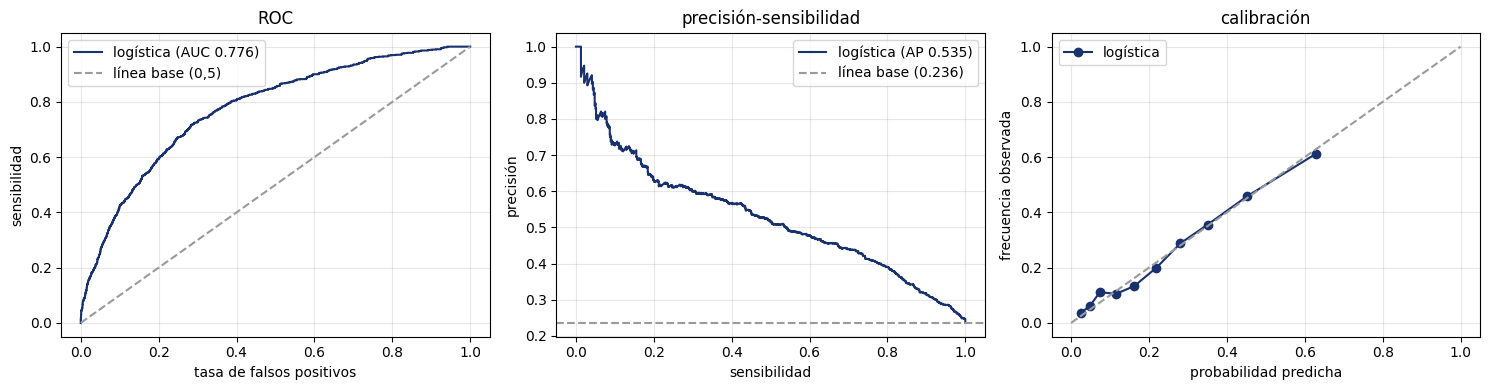

probabilidad media predicha 0.236 vs prevalencia 0.236; 11.1% de los reclamos superan 0,5


In [21]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
fpr, tpr, _ = roc_curve(y_inc, proba_logit)
ejes[0].plot(fpr, tpr, color=AZUL, label=f"logística (AUC {RES_CLF['Logística']['AUC-ROC'].mean():.3f})")
ejes[0].plot([0, 1], [0, 1], color=GRIS, ls="--", label="línea base (0,5)")
ejes[0].set_xlabel("tasa de falsos positivos"); ejes[0].set_ylabel("sensibilidad"); ejes[0].set_title("ROC"); ejes[0].legend()
pr, rc, _ = precision_recall_curve(y_inc, proba_logit)
ejes[1].plot(rc, pr, color=AZUL, label=f"logística (AP {RES_CLF['Logística']['AP (PR-AUC)'].mean():.3f})")
ejes[1].axhline(prevalencia, color=GRIS, ls="--", label=f"línea base ({prevalencia:.3f})")
ejes[1].set_xlabel("sensibilidad"); ejes[1].set_ylabel("precisión"); ejes[1].set_title("precisión-sensibilidad"); ejes[1].legend()
fr, pm = calibration_curve(y_inc, proba_logit, n_bins=10, strategy="quantile")
ejes[2].plot(pm, fr, "o-", color=AZUL, label="logística")
ejes[2].plot([0, 1], [0, 1], color=GRIS, ls="--")
ejes[2].set_xlabel("probabilidad predicha"); ejes[2].set_ylabel("frecuencia observada"); ejes[2].set_title("calibración"); ejes[2].legend()
plt.tight_layout(); plt.show()
print(f"probabilidad media predicha {proba_logit.mean():.3f} vs prevalencia {prevalencia:.3f}; "
      f"{(proba_logit >= 0.5).mean():.1%} de los reclamos superan 0,5")

**Qué métricas se reportan y cuál manda acá, dada la distribución de la respuesta:**

**Lectura de la matriz de confusión:**

**Resultado contra la línea base:**

## 7. Evaluación con validación cruzada

Estimar el desempeño de todos los modelos ajustados hasta acá con validación cruzada de $k$ folds, estratificada en el problema de clasificación. **Reportar media y desvío: ningún número se informa solo.**

La validación cruzada **envuelve al pipeline completo**, no al revés. Y hay decisiones de la sección 1 que tienen que estar tomadas **antes** de particionar: identificar cuáles son y explicar por qué el orden importa.

In [22]:
print(f"REGRESIÓN — KFold({K_FOLDS}, shuffle, semilla {SEMILLA}); cada fila es un pipeline completo")
display(tabla("reg"))
print(f"CLASIFICACIÓN — StratifiedKFold({K_FOLDS}, shuffle, semilla {SEMILLA})")
display(tabla("clf"))

REGRESIÓN — KFold(5, shuffle, semilla 42); cada fila es un pipeline completo


,MAE (h),RMSE (h),MedAE (h),R²,RMSLE,Δ MAE (h) vs base
Línea base: media,82.901 ± 8.171,259.330 ± 108.334,56.408 ± 2.771,-0.002 ± 0.001,2.118 ± 0.030,+0.000 ± 0.000
MCO sobre horas,89.461 ± 6.915,252.624 ± 105.645,52.408 ± 4.241,0.050 ± 0.028,2.110 ± 0.077,+6.560 ± 5.040
MCO sobre log(1 + horas),57.863 ± 10.474,259.318 ± 108.311,12.344 ± 0.819,-0.002 ± 0.008,1.351 ± 0.031,-25.038 ± 2.326
Ridge (λ por VC anidada),57.821 ± 10.454,259.836 ± 108.447,12.231 ± 0.710,-0.006 ± 0.007,1.348 ± 0.030,-25.080 ± 2.312
Lasso (λ por VC anidada),57.849 ± 10.448,259.678 ± 108.196,12.244 ± 0.650,-0.005 ± 0.007,1.350 ± 0.030,-25.052 ± 2.306


CLASIFICACIÓN — StratifiedKFold(5, shuffle, semilla 42)


,AUC-ROC,AP (PR-AUC),Brier,log-loss,Δ AP (PR-AUC) vs base
Línea base: prevalencia,0.500 ± 0.000,0.236 ± 0.001,0.180 ± 0.000,0.547 ± 0.001,+0.000 ± 0.000
Logística,0.776 ± 0.020,0.535 ± 0.036,0.147 ± 0.005,0.456 ± 0.016,+0.299 ± 0.035


In [23]:
### La VC envuelve al pipeline: lo que se estima cambia de fold en fold
filas = []
for i, (tr, va) in enumerate(CV_REG.split(X)):
    p = preprocesador(NUMERICAS, CATEGORICAS).fit(X.iloc[tr])
    num = p.named_transformers_["num"]
    filas.append({"fold": i, "mediana conexiones": num["imputar"].statistics_[1],
                  "media distancia": num["escalar"].mean_[0], "desvío distancia": num["escalar"].scale_[0]})
display(pd.DataFrame(filas).set_index("fold"))

### Por qué deduplicar ANTES de particionar
clave_dup = pd.util.hash_pandas_object(con_reingresos[COLS_SIN_ID], index=False)
y_rein = con_reingresos.incumple.to_numpy()
fold = np.empty(len(con_reingresos), dtype=int)
for i, (_, va) in enumerate(CV_CLF.split(con_reingresos, y_rein)):
    fold[va] = i
grupos = pd.DataFrame({"clave": clave_dup, "fold": fold})
grupos = grupos[grupos.clave.duplicated(keep=False)].groupby("clave").fold.nunique()
print(f"si no se deduplica: {len(grupos)} pares de reingresos; {(grupos > 1).sum()} quedan partidos entre "
      "ajuste y validación → el modelo 'valida' sobre reclamos que ya vio.")
r_rein = cross_validate(logit, con_reingresos[ENTRADA_HONESTA], y_rein, cv=CV_CLF,
                        scoring=["roc_auc", "average_precision"], n_jobs=-1)
print(f"logística con reingresos: AUC {r_rein['test_roc_auc'].mean():.4f} ± {r_rein['test_roc_auc'].std(ddof=1):.4f} "
      f"· sin reingresos: {RES_CLF['Logística']['AUC-ROC'].mean():.4f} ± {RES_CLF['Logística']['AUC-ROC'].std(ddof=1):.4f}")

,mediana conexiones,media distancia,desvío distancia
fold,,,
0,27.0,33.2185,26.8654
1,27.0,33.2553,27.2340
2,27.0,33.1905,27.1671
3,27.0,32.7458,27.0561
4,26.0,33.2105,27.0034


si no se deduplica: 29 pares de reingresos; 26 quedan partidos entre ajuste y validación → el modelo 'valida' sobre reclamos que ya vio.
logística con reingresos: AUC 0.7786 ± 0.0162 · sin reingresos: 0.7756 ± 0.0204


**Resultados con media y desvío:**

**Qué decisiones tuvieron que tomarse antes de particionar, y por qué el orden importa:**

## 8. El costo del leakage: los dos flujos

Construir **dos flujos completos** sobre el problema de clasificación:

- el **honesto**, que excluye las columnas que la sección 2 dejó fuera por no estar disponibles en el momento en que el reclamo ingresa;
- el **contaminado**, que las conserva.

Evaluar los dos con **exactamente la misma** validación cruzada y **reportar la brecha entre ellos como número**.

Los dos flujos difieren **solo en las columnas de entrada**. Si entre uno y otro también cambia el modelo, el preprocesamiento o los folds, la brecha dejó de medir el leakage.

**Declarar el leakage sin medirlo no cumple la consigna.**

In [24]:
NUM_CONT, CAT_CONT = NUMERICAS + POSTERIORES_NUM, CATEGORICAS + POSTERIORES_CAT
X_cont = trabajo[NUM_CONT + CAT_CONT]

# Mismo preprocesador, mismo modelo, mismos folds: solo cambian las columnas de entrada.
flujo_honesto = pipeline_clf(LogisticRegression(max_iter=5000))
flujo_contaminado = pipeline_clf(LogisticRegression(max_iter=5000), NUM_CONT, CAT_CONT)
r_h = evaluar(flujo_honesto, X, y_inc, "Flujo honesto", "clf")
r_c = evaluar(flujo_contaminado, X_cont, y_inc, "Flujo contaminado", "clf")

filas = []
for nombre, r, cols in [("Honesto", r_h, ENTRADA_HONESTA), ("Contaminado", r_c, NUM_CONT + CAT_CONT)]:
    fila = {"Flujo": nombre, "Columnas de entrada": len(cols)}
    for m in ["AUC-ROC", "AP (PR-AUC)", "Brier"]:
        fila[m] = f"{r[m].mean():.4f} ± {r[m].std(ddof=1):.4f}"
        d = r[m] - r_h[m]                      # brecha pareada: mismos folds
        fila[f"brecha {m}"] = "—" if nombre == "Honesto" else f"{d.mean():+.4f} ± {d.std(ddof=1):.4f}"
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Flujo"))
print("columnas que agrega el contaminado:", POSTERIORES_NUM + POSTERIORES_CAT)

,Columnas de entrada,AUC-ROC,brecha AUC-ROC,AP (PR-AUC),brecha AP (PR-AUC),Brier,brecha Brier
Flujo,,,,,,,
Honesto,11,0.7756 ± 0.0204,—,0.5347 ± 0.0361,—,0.1469 ± 0.0052,—
Contaminado,16,0.8626 ± 0.0177,+0.0869 ± 0.0063,0.7413 ± 0.0248,+0.2066 ± 0.0213,0.1110 ± 0.0060,-0.0359 ± 0.0035


columnas que agrega el contaminado: ['calificacion_atencion', 'estado_resuelto', 'tipo_orden', 'grupo_orden', 'centro_tecnico']


In [25]:
### De dónde sale la brecha: agregar una columna posterior por vez
filas = []
for col in POSTERIORES_NUM + POSTERIORES_CAT:
    nn = NUMERICAS + [col] if col in POSTERIORES_NUM else NUMERICAS
    cc = CATEGORICAS + [col] if col in POSTERIORES_CAT else CATEGORICAS
    r = cross_validate(pipeline_clf(LogisticRegression(max_iter=5000), nn, cc), trabajo[nn + cc], y_inc,
                       cv=CV_CLF, scoring={"AUC": "roc_auc", "AP": "average_precision"}, n_jobs=-1)
    filas.append({"columna agregada": col,
                  "Δ AUC": f"{(r['test_AUC'] - r_h['AUC-ROC']).mean():+.4f}",
                  "Δ AP": f"{(r['test_AP'] - r_h['AP (PR-AUC)']).mean():+.4f}"})
display(pd.DataFrame(filas).set_index("columna agregada"))
proba_cont = cross_val_predict(flujo_contaminado, X_cont, y_inc, cv=CV_CLF, method="predict_proba")[:, 1]

,Δ AUC,Δ AP
columna agregada,,
calificacion_atencion,+0.0835,+0.2012
estado_resuelto,+0.0013,-0.0035
tipo_orden,+0.0021,+0.0041
grupo_orden,+0.0001,-0.0025
centro_tecnico,+0.0056,+0.0147


| Flujo | Columnas de entrada | Métrica | Brecha |
|---|---|---|---|
| Honesto | | | — |
| Contaminado | | | |

**Interpretación de la brecha:** qué desempeño aparentaría el modelo en validación y no tendría en producción.

## 9. Elección del umbral por costos

**Derivar** el umbral de probabilidad que minimiza el costo esperado por reclamo, con las cifras del enunciado. Aplicarlo al clasificador de la sección 6 y comparar contra tres alternativas.

Las cuatro políticas se comparan **en dinero**, por reclamo y sobre el volumen anual.

**Coherencia con la sección 6:** si se remuestreó o se ponderaron las clases, las probabilidades quedan descalibradas y el umbral deducido no se aplica sobre ellas sin corregirlas antes.

In [26]:
c = COSTOS
UMBRAL_DEDUCIDO = (c["FP"] - c["VN"]) / ((c["FP"] - c["VN"]) + (c["FN"] - c["VP"]))
print("Priorizar conviene cuando el costo esperado de priorizar es menor que el de no hacerlo:")
print("   p·C_VP + (1−p)·C_FP  <  p·C_FN + (1−p)·C_VN")
print("   ⇔ p > (C_FP − C_VN) / [(C_FP − C_VN) + (C_FN − C_VP)]")
print(f"   = ({c['FP']:,} − {c['VN']:,}) / [({c['FP']:,} − {c['VN']:,}) + ({c['FN']:,} − {c['VP']:,})] "
      f"= {UMBRAL_DEDUCIDO:.4f}")
print(f"\nRequiere probabilidades calibradas: la logística no ponderó clases; media predicha "
      f"{proba_logit.mean():.3f} vs prevalencia {prevalencia:.3f}.")


def costo_por_fold(decision):
    """Costo medio por reclamo en cada fold de validación, dada la decisión de priorizar (0/1)."""
    out = []
    for va in FOLDS_CLF:
        y, d = y_inc[va], decision[va]
        costo = (c["VP"] * (d & (y == 1)) + c["FP"] * (d & (y == 0))
                 + c["FN"] * (~d & (y == 1)) + c["VN"] * (~d & (y == 0)))
        out.append(costo.mean())
    return np.array(out)


POLITICAS = {
    f"Umbral deducido ({UMBRAL_DEDUCIDO:.3f})": proba_logit >= UMBRAL_DEDUCIDO,
    "Umbral 0,5": proba_logit >= 0.5,
    "Priorizar todos": np.ones(len(y_inc), bool),
    "No priorizar ninguno": np.zeros(len(y_inc), bool),
}
COSTO_POLITICA = {n: costo_por_fold(d) for n, d in POLITICAS.items()}
ref = COSTO_POLITICA["No priorizar ninguno"]
tabla_costos = pd.DataFrame({
    n: {"% priorizado": f"{d.mean():.1%}",
        "Costo por reclamo ($U)": f"{v.mean():,.0f} ± {v.std(ddof=1):,.0f}",
        "Costo anual ($U)": f"{v.mean() * VOLUMEN_ANUAL:,.0f}",
        "Ahorro anual vs no priorizar ($U)": f"{(ref.mean() - v.mean()) * VOLUMEN_ANUAL:,.0f}"}
    for (n, d), v in zip(POLITICAS.items(), COSTO_POLITICA.values())}).T
print(f"\nvolumen anual: {VOLUMEN_ANUAL:,} reclamos")
display(tabla_costos)

Priorizar conviene cuando el costo esperado de priorizar es menor que el de no hacerlo:
   p·C_VP + (1−p)·C_FP  <  p·C_FN + (1−p)·C_VN
   ⇔ p > (C_FP − C_VN) / [(C_FP − C_VN) + (C_FN − C_VP)]
   = (2,000 − 0) / [(2,000 − 0) + (10,000 − 2,000)] = 0.2000

Requiere probabilidades calibradas: la logística no ponderó clases; media predicha 0.236 vs prevalencia 0.236.

volumen anual: 390,886 reclamos


,% priorizado,Costo por reclamo ($U),Costo anual ($U),Ahorro anual vs no priorizar ($U)
Umbral deducido (0.200),48.4%,"1,437 ± 53","561,605,114","361,380,402"
"Umbral 0,5",11.1%,"1,908 ± 36","745,983,251","177,002,265"
Priorizar todos,100.0%,"2,000 ± 0","781,772,000","141,213,516"
No priorizar ninguno,0.0%,"2,361 ± 6","922,985,516",0


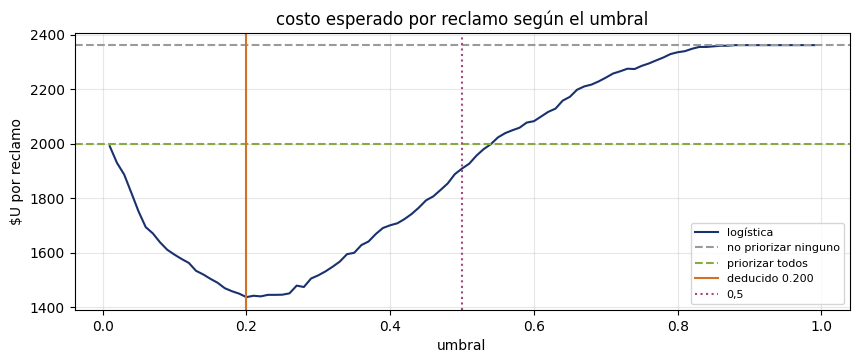

mínimo empírico en 0.20 (1,437 $U) vs deducido 0.200 (1,437 $U): el umbral se deduce, no se busca.

Línea base de la sección 3 con el umbral deducido: la prevalencia (0.236) supera 0.200 → equivale a 'Priorizar todos' (2,000 $U por reclamo).
Lo que aparentaría el flujo contaminado (sección 8): 1,258 $U por reclamo, 431,238,097 $U de ahorro anual que no existe en producción.


In [27]:
umbrales = np.linspace(0.01, 0.99, 99)
curva = np.array([costo_por_fold(proba_logit >= u).mean() for u in umbrales])
u_emp = umbrales[curva.argmin()]
fig, eje = plt.subplots(figsize=(10, 3.6))
eje.plot(umbrales, curva, color=AZUL, label="logística")
eje.axhline(ref.mean(), color=GRIS, ls="--", label="no priorizar ninguno")
eje.axhline(COSTO_POLITICA["Priorizar todos"].mean(), color=OLIVA, ls="--", label="priorizar todos")
eje.axvline(UMBRAL_DEDUCIDO, color=NARANJA, label=f"deducido {UMBRAL_DEDUCIDO:.3f}")
eje.axvline(0.5, color=VIOLETA, ls=":", label="0,5")
eje.set_xlabel("umbral"); eje.set_ylabel("$U por reclamo"); eje.set_title("costo esperado por reclamo según el umbral")
eje.legend(fontsize=8); plt.show()
print(f"mínimo empírico en {u_emp:.2f} ({curva.min():,.0f} $U) vs deducido {UMBRAL_DEDUCIDO:.3f} "
      f"({costo_por_fold(proba_logit >= UMBRAL_DEDUCIDO).mean():,.0f} $U): el umbral se deduce, no se busca.")

d_base = proba_base >= UMBRAL_DEDUCIDO
print(f"\nLínea base de la sección 3 con el umbral deducido: la prevalencia ({prevalencia:.3f}) "
      f"{'supera' if prevalencia >= UMBRAL_DEDUCIDO else 'no supera'} {UMBRAL_DEDUCIDO:.3f} → equivale a "
      f"'{'Priorizar todos' if d_base.all() else 'No priorizar ninguno'}' "
      f"({costo_por_fold(d_base).mean():,.0f} $U por reclamo).")
v_cont = costo_por_fold(proba_cont >= UMBRAL_DEDUCIDO)
print(f"Lo que aparentaría el flujo contaminado (sección 8): {v_cont.mean():,.0f} $U por reclamo, "
      f"{(ref.mean() - v_cont.mean()) * VOLUMEN_ANUAL:,.0f} $U de ahorro anual que no existe en producción.")

**Derivación del umbral:**

| Política | Costo por reclamo | Costo anual |
|---|---|---|
| Umbral deducido | | |
| Umbral 0,5 | | |
| Priorizar todos | | |
| No priorizar ninguno | | |

**Lectura de la comparación:**

## 10. Tres familias bajo el mismo defecto

Ajustar **k vecinos más cercanos** y un **árbol de decisión**, cada uno con su hiperparámetro elegido por validación cruzada, **dos veces**: sobre los datos bien preparados y sobre los mismos datos **sin escalar**. Someter al modelo lineal de la sección 4 **al mismo cambio**.

Repetir el ejercicio **cambiando la unidad de una de las variables continuas**, y reportar todo en **una sola tabla** con las tres familias.

- **No es una sección de modelado.** No importa cuál de las tres gana. Los únicos hiperparámetros que se ajustan son el $k$ de k vecinos y la profundidad del árbol.
- **Las grillas se declaran y tienen que llegar lo bastante alto.** Si el valor elegido queda pegado a un borde, el barrido se cortó antes del óptimo.
- Entre una rama y otra **puede cambiar una sola cosa**.

> **Costo de cómputo.** Una grilla razonable para $k$ es $\{1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 61, 81, 101, 151, 201, 301, 401\}$ y para la profundidad, $\{2, 3, 4, 5, 6, 8, 10, 12, \text{sin límite}\}$. Con cuatro combinaciones de preparación y validación cruzada de 5 folds son varios cientos de ajustes: **minutos, no segundos**. Conviene correr las combinaciones una sola vez y guardar los resultados. Puede usarse otra grilla, siempre que se declare y llegue igual de alto.

In [28]:
GRILLA_K = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 61, 81, 101, 151, 201, 301, 401]
GRILLA_PROF = [2, 3, 4, 5, 6, 8, 10, 12, None]
AMPLIACION_K = [601, 801, 1201, 1601, 2001, 2401]   # se agrega solo si k* cae en 401 (borde superior)
VAR_UNIDAD, FACTOR_UNIDAD = "distancia_centro_km", 1000   # la distancia pasa de km a metros
PREPARACIONES = [("Escalado, unidad original", True, False), ("Escalado, unidad cambiada", True, True),
                 ("Sin escalar, unidad original", False, False), ("Sin escalar, unidad cambiada", False, True)]
# Entre ramas cambia una sola cosa: el StandardScaler de las numéricas, o la unidad de la distancia.
# Las tres familias usan la misma respuesta (log(1 + horas)) y se comparan en MAE en horas.


def correr_rama(escalar, cambiada):
    Xr = X.copy()
    if cambiada:
        Xr[VAR_UNIDAD] = Xr[VAR_UNIDAD] * FACTOR_UNIDAD
    r = cross_validate(pipeline_reg(LinearRegression(), escalar=escalar), Xr, y_horas, cv=CV_REG,
                       scoring="neg_mean_absolute_error", n_jobs=-1)
    fila = {"lineal": [float(-r["test_score"].mean()), float(r["test_score"].std(ddof=1))]}
    for nombre, est, param, grilla in [("knn", KNeighborsRegressor(), "n_neighbors", GRILLA_K),
                                       ("arbol", DecisionTreeRegressor(random_state=SEMILLA), "max_depth", GRILLA_PROF)]:
        while True:
            gs = GridSearchCV(pipeline_reg(est, escalar=escalar), {f"regressor__modelo__{param}": grilla},
                              cv=CV_REG, scoring="neg_mean_absolute_error", n_jobs=-1).fit(Xr, y_horas)
            i = int(gs.best_index_)
            if nombre == "knn" and i == len(grilla) - 1 and grilla[-1] < AMPLIACION_K[-1]:
                grilla = grilla + [k for k in AMPLIACION_K if k > grilla[-1]][:2]
                continue
            break
        splits = [-gs.cv_results_[f"split{j}_test_score"][i] for j in range(K_FOLDS)]
        fila[nombre] = [float(np.mean(splits)), float(np.std(splits, ddof=1)), i,
                        (-gs.cv_results_["mean_test_score"]).tolist(), grilla]
    return fila


RUTA_RESULTADOS.mkdir(exist_ok=True)
CACHE_10 = RUTA_RESULTADOS / "seccion10.json"
firma = {"n": len(X), "suma_y": round(float(y_horas.sum()), 4), "semilla": SEMILLA, "folds": K_FOLDS,
         "k": GRILLA_K, "ampl": AMPLIACION_K, "prof": [str(p) for p in GRILLA_PROF], "factor": FACTOR_UNIDAD, "entrada": ENTRADA_HONESTA}
cache = json.loads(CACHE_10.read_text()) if CACHE_10.exists() else {}
if cache.get("firma") == firma:
    RES10 = cache["resultados"]
    print(f"resultados leídos de {CACHE_10} (misma firma de datos, grillas y semilla)")
else:
    RES10 = {nombre: correr_rama(esc, camb) for nombre, esc, camb in PREPARACIONES}
    CACHE_10.write_text(json.dumps({"firma": firma, "resultados": RES10}, ensure_ascii=False))
    print(f"resultados calculados y guardados en {CACHE_10}")

resultados calculados y guardados en resultados\seccion10.json


Sin escalar, unidad cambiada: k* cayó en 401 (borde); la grilla se amplió hasta 801 y k* = 401 quedó interior
MAE en horas, VC de 5 folds (media ± desvío) · línea base: 82.90 h


,Lineal,k vecinos,k*,Árbol,profundidad*
Preparación,,,,,
"Escalado, unidad original",57.86 ± 10.47,57.80 ± 10.75,15,57.17 ± 10.31,5
"Escalado, unidad cambiada",57.86 ± 10.47,57.80 ± 10.75,15,57.17 ± 10.31,5
"Sin escalar, unidad original",57.86 ± 10.47,60.45 ± 10.37,31,57.17 ± 10.31,5
"Sin escalar, unidad cambiada",57.86 ± 10.47,60.35 ± 10.39,401,57.17 ± 10.31,5


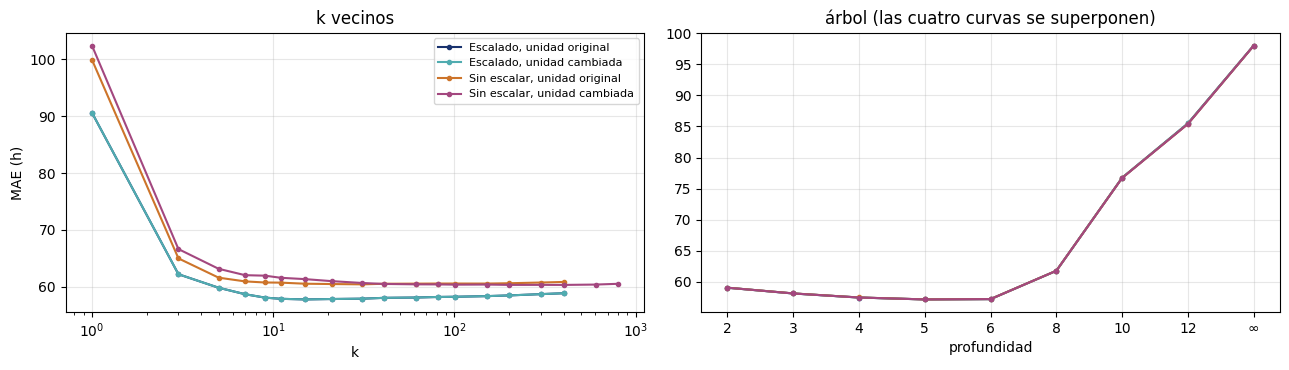

In [29]:
fmt = lambda m, s: f"{m:.2f} ± {s:.2f}"
filas = []
for nombre, _, _ in PREPARACIONES:
    r = RES10[nombre]
    k_i, p_i, grilla_k = r["knn"][2], r["arbol"][2], r["knn"][4]
    filas.append({"Preparación": nombre, "Lineal": fmt(*r["lineal"]), "k vecinos": fmt(*r["knn"][:2]),
                  "k*": grilla_k[k_i], "Árbol": fmt(*r["arbol"][:2]),
                  "profundidad*": "sin límite" if GRILLA_PROF[p_i] is None else GRILLA_PROF[p_i]})
    if len(grilla_k) > len(GRILLA_K):
        print(f"{nombre}: k* cayó en {GRILLA_K[-1]} (borde); la grilla se amplió hasta {grilla_k[-1]} "
              f"y k* = {grilla_k[k_i]} quedó {'interior' if k_i < len(grilla_k) - 1 else 'en el borde'}")
    for fam, i, grilla in [("k", k_i, grilla_k), ("profundidad", p_i, GRILLA_PROF)]:
        if i in (0, len(grilla) - 1):
            print(f"⚠ {nombre}: {fam}* sigue en el borde de la grilla")
print(f"MAE en horas, VC de {K_FOLDS} folds (media ± desvío) · línea base: {LB['MAE (h)']:.2f} h")
display(pd.DataFrame(filas).set_index("Preparación"))

fig, ejes = plt.subplots(1, 2, figsize=(13, 3.8))
for (nombre, _, _), color in zip(PREPARACIONES, [AZUL, TURQUESA, NARANJA, VIOLETA]):
    ejes[0].semilogx(RES10[nombre]["knn"][4], RES10[nombre]["knn"][3], "o-", ms=3, color=color, label=nombre)
    ejes[1].plot(range(len(GRILLA_PROF)), RES10[nombre]["arbol"][3], "o-", ms=3, color=color, label=nombre)
ejes[0].set_xlabel("k"); ejes[0].set_ylabel("MAE (h)"); ejes[0].set_title("k vecinos"); ejes[0].legend(fontsize=8)
ejes[1].set_xticks(range(len(GRILLA_PROF)), [str(p) if p else "∞" for p in GRILLA_PROF])
ejes[1].set_xlabel("profundidad"); ejes[1].set_title("árbol (las cuatro curvas se superponen)")
plt.tight_layout(); plt.show()

**Grillas declaradas:**

| Preparación | Lineal | k vecinos | $k^\star$ | Árbol | profundidad$^\star$ |
|---|---|---|---|---|---|
| Escalado, unidad original | | | | | |
| Escalado, unidad cambiada | | | | | |
| Sin escalar, unidad original | | | | | |
| Sin escalar, unidad cambiada | | | | | |

**Qué le hace la preparación a cada familia, y por qué las tres no se comportan igual:**

## 11. Reglas de decisión

Ajustar un árbol de clasificación **deliberadamente pequeño** —una profundidad que un supervisor de guardia pueda leer— y **extraer sus reglas en lenguaje del caso**: la ruta de la raíz a cada hoja, traducida a una condición operativa sobre reclamos.

Para cada hoja, reportar **cuántos reclamos caen en ella y qué proporción de ellos incumple el plazo**, y contrastar esa proporción con la prevalencia general. Una hoja que no se aparta de la prevalencia no es una regla: es la media disfrazada.

Comparar el desempeño de ese árbol pequeño contra el clasificador de la sección 6 y discutir **qué se pierde y qué se gana** al reemplazar un modelo por un puñado de reglas. La discusión tiene que hablar de la operación —quién aplica la regla, con qué información y en cuánto tiempo—, no solo de métricas.

**Este es el único punto de la entrega donde se pide interpretabilidad**, y se pide como reglas explícitas, no como importancias de variables.

In [30]:
MIN_HOJA = 30    # una hoja con menos reclamos no sostiene una regla
filas = []
for d in [1, 2, 3, 4, 5, 6]:
    r = cross_validate(pipeline_clf(DecisionTreeClassifier(max_depth=d, min_samples_leaf=MIN_HOJA,
                                                           random_state=SEMILLA), escalar=False),
                       X, y_inc, cv=CV_CLF, scoring={"AUC": "roc_auc", "AP": "average_precision"}, n_jobs=-1)
    filas.append({"profundidad": d, "hojas máx.": 2 ** d, "AUC": fmt(r["test_AUC"].mean(), r["test_AUC"].std(ddof=1)),
                  "AP": fmt(r["test_AP"].mean(), r["test_AP"].std(ddof=1))})
display(pd.DataFrame(filas).set_index("profundidad"))

PROF_REGLAS = 3
arbol_reglas = pipeline_clf(DecisionTreeClassifier(max_depth=PROF_REGLAS, min_samples_leaf=MIN_HOJA,
                                                   random_state=SEMILLA), escalar=False)   # umbrales en km
_ = evaluar(arbol_reglas, X, y_inc, f"Árbol de reglas (prof. {PROF_REGLAS})", "clf")

,hojas máx.,AUC,AP
profundidad,,,
1,2,0.66 ± 0.01,0.32 ± 0.01
2,4,0.71 ± 0.01,0.38 ± 0.01
3,8,0.75 ± 0.01,0.44 ± 0.02
4,16,0.77 ± 0.02,0.48 ± 0.02
5,32,0.79 ± 0.02,0.51 ± 0.03
6,64,0.79 ± 0.02,0.52 ± 0.03


In [31]:
arbol_reglas.fit(X, y_inc)
arbol = arbol_reglas.named_steps["modelo"].tree_
nombres_a = arbol_reglas.named_steps["prep"].get_feature_names_out()
ETIQUETA = {"distancia_centro_km": ("distancia al centro", "km"), "conexiones_afectadas": ("conexiones afectadas", "")}


def condicion(nombre, umbral, izquierda):
    if nombre.startswith("num__"):
        etiqueta, unidad = ETIQUETA[nombre[5:]]
        return f"{etiqueta} {'≤' if izquierda else '>'} {umbral:.1f} {unidad}".strip()
    var, nivel = separar(nombre)
    nivel = "un nivel poco frecuente" if nivel == "infrequent_sklearn" else f"«{nivel}»"
    return f"{var} {'no es' if izquierda else 'es'} {nivel}"


rutas = {}
def recorrer(nodo, conds):
    if arbol.children_left[nodo] == -1:
        rutas[nodo] = conds
        return
    f, u = nombres_a[arbol.feature[nodo]], arbol.threshold[nodo]
    recorrer(arbol.children_left[nodo], conds + [condicion(f, u, True)])
    recorrer(arbol.children_right[nodo], conds + [condicion(f, u, False)])
recorrer(0, [])

hoja = arbol_reglas.named_steps["modelo"].apply(arbol_reglas.named_steps["prep"].transform(X))
filas = []
for nodo, conds in rutas.items():
    en = hoja == nodo
    n, k = int(en.sum()), int(y_inc[en].sum())
    filas.append({"Regla": "SI " + " Y ".join(conds), "Reclamos": n, "Tasa de incumplimiento": k / n,
                  "vs prevalencia (pp)": (k / n - prevalencia) * 100, "× prevalencia": k / n / prevalencia,
                  "p binomial": stats.binomtest(k, n, prevalencia).pvalue,
                  f"prioriza (tasa ≥ {UMBRAL_DEDUCIDO:.3f})": k / n >= UMBRAL_DEDUCIDO})
reglas = pd.DataFrame(filas).sort_values("Tasa de incumplimiento", ascending=False).reset_index(drop=True)
reglas.index += 1
print(f"prevalencia general {prevalencia:.1%}; {len(reglas)} hojas; ajustado sobre los {len(X):,} reclamos")
with pd.option_context("display.max_colwidth", None):
    display(reglas.style.format({"Tasa de incumplimiento": "{:.1%}", "vs prevalencia (pp)": "{:+.1f}",
                                 "× prevalencia": "{:.2f}", "p binomial": "{:.2g}"}))

prevalencia general 23.6%; 8 hojas; ajustado sobre los 3,604 reclamos


,Regla,Reclamos,Tasa de incumplimiento,vs prevalencia (pp),× prevalencia,p binomial,prioriza (tasa ≥ 0.200)
1,SI ausencia_agua es «CON AGUA» Y dia_semana es «5 viernes» Y distancia al centro > 6.7 km,322,62.4%,+38.8,2.64,1.5e-49,True
2,SI ausencia_agua es «CON AGUA» Y dia_semana no es «5 viernes» Y departamento es «MONTEVIDEO»,757,38.8%,+15.2,1.64,1.2e-20,True
3,SI ausencia_agua no es «CON AGUA» Y distancia al centro > 7.5 km Y dia_semana es «6 sábado»,89,27.0%,+3.4,1.14,0.45,True
4,SI ausencia_agua es «CON AGUA» Y dia_semana es «5 viernes» Y distancia al centro ≤ 6.7 km,58,22.4%,-1.2,0.95,1,True
5,SI ausencia_agua es «CON AGUA» Y dia_semana no es «5 viernes» Y departamento no es «MONTEVIDEO»,1114,21.4%,-2.2,0.90,0.078,True
6,SI ausencia_agua no es «CON AGUA» Y distancia al centro > 7.5 km Y dia_semana no es «6 sábado»,822,8.8%,-14.9,0.37,2e-28,False
7,SI ausencia_agua no es «CON AGUA» Y distancia al centro ≤ 7.5 km Y distancia al centro > 2.6 km,154,3.9%,-19.7,0.17,2.8e-11,False
8,SI ausencia_agua no es «CON AGUA» Y distancia al centro ≤ 7.5 km Y distancia al centro ≤ 2.6 km,288,1.0%,-22.6,0.04,4.2e-29,False


In [32]:
nombre_arbol = f"Árbol de reglas (prof. {PROF_REGLAS})"
display(tabla("clf", [BASE_CLF, "Logística", nombre_arbol]))
proba_arbol = cross_val_predict(arbol_reglas, X, y_inc, cv=CV_CLF, method="predict_proba")[:, 1]
v_arbol = costo_por_fold(proba_arbol >= UMBRAL_DEDUCIDO)
v_logit = COSTO_POLITICA[f"Umbral deducido ({UMBRAL_DEDUCIDO:.3f})"]
display(pd.DataFrame({
    "Costo por reclamo ($U)": {"Logística + umbral deducido": fmt(v_logit.mean(), v_logit.std(ddof=1)),
                               "Reglas del árbol + umbral deducido": fmt(v_arbol.mean(), v_arbol.std(ddof=1)),
                               "No priorizar ninguno": fmt(ref.mean(), ref.std(ddof=1))},
    "Costo anual ($U)": {"Logística + umbral deducido": f"{v_logit.mean() * VOLUMEN_ANUAL:,.0f}",
                         "Reglas del árbol + umbral deducido": f"{v_arbol.mean() * VOLUMEN_ANUAL:,.0f}",
                         "No priorizar ninguno": f"{ref.mean() * VOLUMEN_ANUAL:,.0f}"}}))
print(f"reemplazar la logística por las reglas cuesta {(v_arbol.mean() - v_logit.mean()) * VOLUMEN_ANUAL:+,.0f} $U al año")

,AUC-ROC,AP (PR-AUC),Brier,log-loss,Δ AP (PR-AUC) vs base
Línea base: prevalencia,0.500 ± 0.000,0.236 ± 0.001,0.180 ± 0.000,0.547 ± 0.001,+0.000 ± 0.000
Logística,0.776 ± 0.020,0.535 ± 0.036,0.147 ± 0.005,0.456 ± 0.016,+0.299 ± 0.035
Árbol de reglas (prof. 3),0.753 ± 0.009,0.437 ± 0.015,0.152 ± 0.002,0.467 ± 0.007,+0.201 ± 0.015


,Costo por reclamo ($U),Costo anual ($U)
Logística + umbral deducido,1436.75 ± 52.74,"561,605,114"
Reglas del árbol + umbral deducido,1526.09 ± 25.21,"596,527,034"
No priorizar ninguno,2361.27 ± 6.01,"922,985,516"


reemplazar la logística por las reglas cuesta +34,921,920 $U al año


**Profundidad elegida y por qué:**

| # | Regla, en lenguaje del caso | Reclamos | Tasa de incumplimiento | Contra la prevalencia |
|---|---|---|---|---|

**Desempeño del árbol pequeño contra el clasificador de la sección 6:**

**Qué se pierde y qué se gana al reemplazar el modelo por estas reglas, en términos de la operación:**

## 12. Autocrítica del flujo

**Sin código: es texto**, y **se escribe al final, sobre el flujo propio**, releyendo lo que el grupo efectivamente hizo en las secciones anteriores.

Identificar **la decisión metodológica más frágil del propio trabajo** —una sola, elegida y argumentada—, explicar **qué la haría fallar** y qué evidencia adicional la confirmaría o la descartaría.

No se acepta una fragilidad genérica del aprendizaje automático ni una limitación abstracta del conjunto de datos. La respuesta tiene que **nombrar una decisión que el grupo tomó**, en una sección concreta, y decir **qué número del notebook cambiaría** si esa decisión estuviera mal. Tampoco cuenta una fragilidad que el propio notebook ya resolvió.

Rúbrica: identificar la falencia (2), explicar cómo afecta al modelo (2), proponer la corrección (1).

**La decisión más frágil, y en qué sección se tomó:**

**Qué la haría fallar, y qué número del notebook cambiaría:**

**Qué evidencia adicional la confirmaría o la descartaría:**

## 13. Conclusiones y límites

Qué se recomienda a la organización, con qué desempeño y a qué costo, **contra la línea base de la sección 3 y expresado en dinero**.

Y **qué no se puede concluir con estos datos**. Los límites tienen que ser los de este caso —los que la auditoría de la sección 1 y la evaluación de la sección 7 dejaron a la vista—, no una lista genérica de advertencias sobre el aprendizaje automático. Entre ellos, el que impone trabajar sobre un registro parcialmente construido con fines didácticos.

In [33]:
mejor_reg = min((n for n in RES_REG if n != BASE_REG), key=lambda n: RES_REG[n]["MAE (h)"].mean())
resumen = pd.DataFrame({
    "Línea base (sección 3)": {
        "MAE (h)": fmt(LB["MAE (h)"], RES_REG[BASE_REG]["MAE (h)"].std(ddof=1)),
        "AP (PR-AUC)": fmt(LB["AP (PR-AUC)"], RES_CLF[BASE_CLF]["AP (PR-AUC)"].std(ddof=1)),
        "AUC-ROC": fmt(LB["AUC-ROC"], 0),
        "Costo por reclamo ($U)": fmt(costo_por_fold(d_base).mean(), costo_por_fold(d_base).std(ddof=1)),
        "Costo anual ($U)": f"{costo_por_fold(d_base).mean() * VOLUMEN_ANUAL:,.0f}"},
    "Modelo recomendado": {
        "MAE (h)": f"{fmt(RES_REG[mejor_reg]['MAE (h)'].mean(), RES_REG[mejor_reg]['MAE (h)'].std(ddof=1))} ({mejor_reg})",
        "AP (PR-AUC)": fmt(RES_CLF["Logística"]["AP (PR-AUC)"].mean(), RES_CLF["Logística"]["AP (PR-AUC)"].std(ddof=1)),
        "AUC-ROC": fmt(RES_CLF["Logística"]["AUC-ROC"].mean(), RES_CLF["Logística"]["AUC-ROC"].std(ddof=1)),
        "Costo por reclamo ($U)": fmt(v_logit.mean(), v_logit.std(ddof=1)),
        "Costo anual ($U)": f"{v_logit.mean() * VOLUMEN_ANUAL:,.0f}"},
})
display(resumen)
ahorro = (costo_por_fold(d_base) - v_logit) * VOLUMEN_ANUAL
print(f"Ahorro anual de la logística con umbral {UMBRAL_DEDUCIDO:.3f} frente a la línea base: "
      f"{ahorro.mean():,.0f} ± {ahorro.std(ddof=1):,.0f} $U (desvío entre folds)")
print(f"Supuestos a la vista: plazo {PLAZO_HORAS} h, costos {COSTOS}, volumen {VOLUMEN_ANUAL:,} reclamos/año.")

,Línea base (sección 3),Modelo recomendado
MAE (h),82.90 ± 8.17,57.82 ± 10.45 (Ridge (λ por VC anidada))
AP (PR-AUC),0.24 ± 0.00,0.53 ± 0.04
AUC-ROC,0.50 ± 0.00,0.78 ± 0.02
Costo por reclamo ($U),2000.00 ± 0.00,1436.75 ± 52.74
Costo anual ($U),"781,772,000","561,605,114"


Ahorro anual de la logística con umbral 0.200 frente a la línea base: 220,166,886 ± 20,613,910 $U (desvío entre folds)
Supuestos a la vista: plazo 48 h, costos {'VP': 2000, 'FP': 2000, 'FN': 10000, 'VN': 0}, volumen 390,886 reclamos/año.


**Recomendación, con su desempeño y su costo:**

**Qué no se puede concluir con estos datos:**